# VERİ ANALİZİ DERSİ DÜNYA MUTLULUK RAPORU - METEHAN AYHAN

Bu proje, dünya çapında ülkelerin mutluluk seviyelerini değerlendiren **Dünya Mutluluk Raporu (World Happiness Report)** verilerini kullanarak, **gelecek 5 yıl için mutluluk seviyelerinin nasıl değişebileceğini tahmin etmeyi** amaçlamaktadır. 

Projede:
- **Zaman serisi analizi** kullanılarak küresel mutluluk seviyelerinin yıllara göre nasıl değiştiği incelenecek,
- **Regresyon ve makine öğrenmesi yöntemleri** ile mutluluğu etkileyen faktörler belirlenecek,
- **Politika önerileri** geliştirilecek.

Veri seti **2006 - 2022** yılları arasında dünya genelindeki ülkelerin mutluluk seviyelerini ve bu seviyeleri etkileyen ekonomik, sosyal ve psikolojik faktörleri içermektedir. Bu projede eksik veri analizi, veri temizleme, görselleştirme ve modelleme adımları takip edilerek **gelecek 5 yıl için bir tahmin yapılacaktır.**

## Veri Sözlüğü

Bu veri seti, dünya çapında ülkelerin mutluluk seviyelerini ve ilgili değişkenleri içermektedir.

| Değişken Adı                      | Açıklama |
|-----------------------------------|------------------------------------------------|
| **Country Name**                  | Ülke adı |
| **Regional Indicator**            | Ülkenin ait olduğu bölge (Örn: Avrupa, Güney Asya) |
| **Year**                          | Verinin ait olduğu yıl |
| **Life Ladder**                   | Mutluluk skoru (0-10 arası) |
| **Log GDP Per Capita**            | Kişi başına düşen GSYİH’nin logaritması |
| **Social Support**                | Kişinin zor zamanlarında destek alabileceği birine sahip olma oranı |
| **Healthy Life Expectancy At Birth** | Doğumda beklenen sağlıklı yaşam süresi |
| **Freedom To Make Life Choices**   | Kendi yaşam seçimlerini yapabilme özgürlüğü (0-1 arası) |
| **Generosity**                     | Bağış yapma eğilimi (negatif değerler bağışın yaygın olmadığını gösterir) |
| **Perceptions Of Corruption**      | Ülkedeki yolsuzluk algısı (1 = Çok yolsuzluk var, 0 = Yolsuzluk algısı düşük) |
| **Positive Affect**                | Olumlu duyguların (mutluluk, kahkaha vb.) günlük yaşamdaki ortalama oranı |
| **Negative Affect**                | Olumsuz duyguların (endişe, üzüntü vb.) günlük yaşamdaki ortalama oranı |
| **Confidence In National Government** | Ulusal hükümete duyulan güven seviyesi |

### Gerekli Kütüphaneleri Yükleyelim

In [1]:
import pandas as pd
pd.set_option("display.max_columns",250)
pd.set_option('display.max_rows', 250)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

### Import Data

In [2]:
df=pd.read_csv('WorldHappinessReport.csv')

In [3]:
df.head(50)

,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
0,Afghanistan,South Asia,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,South Asia,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,South Asia,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,South Asia,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,South Asia,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,0.613513,0.267919,0.435440
5,Afghanistan,South Asia,2013,3.572100,7.680333,0.483552,52.000000,0.577955,0.062666,0.823204,0.547417,0.273328,0.482847
6,Afghanistan,South Asia,2014,3.130896,7.670638,0.525568,52.299999,0.508514,0.105755,0.871242,0.491641,0.374861,0.409048
7,Afghanistan,South Asia,2015,3.982855,7.653833,0.528597,52.599998,0.388928,0.081652,0.880638,0.491410,0.339276,0.260557
8,Afghanistan,South Asia,2016,4.220169,7.650370,0.559072,52.924999,0.522566,0.043916,0.793246,0.501409,0.348332,0.324990
9,Afghanistan,South Asia,2017,2.661718,7.647830,0.490880,53.250000,0.427011,-0.119410,0.954393,0.435270,0.371326,0.261179


In [4]:
df.tail(50)

,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
2149,Vietnam,Southeast Asia,2017,5.175279,9.110596,NaN,65.099998,NaN,NaN,NaN,NaN,NaN,NaN
2150,Vietnam,Southeast Asia,2018,5.295547,9.173263,0.831945,65.199997,0.909260,-0.060768,0.808423,0.614404,0.191061,NaN
2151,Vietnam,Southeast Asia,2019,5.467451,9.235229,0.847592,65.300003,0.952469,-0.145854,0.787889,0.657786,0.185610,NaN
2152,Vietnam,Southeast Asia,2020,5.462342,9.254416,0.764510,65.400002,0.944707,0.065848,0.791134,0.699165,0.286374,NaN
2153,Vietnam,Southeast Asia,2021,5.540250,9.271268,0.799494,65.500000,0.896800,0.106941,0.797788,0.650598,0.280437,NaN
2154,Vietnam,Southeast Asia,2022,6.266509,9.332854,0.878744,65.599998,0.975405,-0.178987,0.703423,0.774236,0.108473,NaN
2155,Yemen,Middle East and North Africa,2007,4.477133,8.211859,0.824969,58.720001,0.672685,0.009045,NaN,0.523652,0.378784,0.465138
2156,Yemen,Middle East and North Africa,2009,4.809259,8.250217,0.756430,58.639999,0.644229,-0.052437,0.832427,0.510788,0.374160,0.552199
2157,Yemen,Middle East and North Africa,2010,4.350313,8.413556,0.726612,58.599998,0.659284,-0.103785,0.853403,0.513613,0.308333,0.520393
2158,Yemen,Middle East and North Africa,2011,3.746256,8.263951,0.662680,58.560001,0.638211,-0.170486,0.753882,0.415945,0.284863,0.387044


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country Name                       2199 non-null   object 
 1   Regional Indicator                 2087 non-null   object 
 2   Year                               2199 non-null   int64  
 3   Life Ladder                        2199 non-null   float64
 4   Log GDP Per Capita                 2179 non-null   float64
 5   Social Support                     2186 non-null   float64
 6   Healthy Life Expectancy At Birth   2145 non-null   float64
 7   Freedom To Make Life Choices       2166 non-null   float64
 8   Generosity                         2126 non-null   float64
 9   Perceptions Of Corruption          2083 non-null   float64
 10  Positive Affect                    2175 non-null   float64
 11  Negative Affect                    2183 non-null   float

In [6]:
df.describe()

,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
count,2199.000000,2199.000000,2179.000000,2186.000000,2145.000000,2166.000000,2126.000000,2083.000000,2175.000000,2183.000000,1838.000000
mean,2014.161437,5.479226,9.389766,0.810679,63.294583,0.747858,0.000096,0.745195,0.652143,0.271501,0.483999
std,4.718736,1.125529,1.153387,0.120952,6.901104,0.140150,0.161083,0.185837,0.105922,0.086875,0.193071
min,2005.000000,1.281271,5.526723,0.228217,6.720000,0.257534,-0.337527,0.035198,0.178886,0.082737,0.068769
25%,2010.000000,4.646750,8.499764,0.746609,59.119999,0.656528,-0.112116,0.688139,0.571684,0.207660,0.332549
50%,2014.000000,5.432437,9.498955,0.835535,65.050003,0.769821,-0.022671,0.799654,0.663063,0.260671,0.467140
75%,2018.000000,6.309460,10.373216,0.904792,68.500000,0.859382,0.092070,0.868827,0.737936,0.322894,0.618846
max,2022.000000,8.018934,11.663788,0.987343,74.474998,0.985178,0.702708,0.983276,0.883586,0.704590,0.993604


In [7]:
df.isnull().sum()

Country Name                           0
Regional Indicator                   112
Year                                   0
Life Ladder                            0
Log GDP Per Capita                    20
Social Support                        13
Healthy Life Expectancy At Birth      54
Freedom To Make Life Choices          33
Generosity                            73
Perceptions Of Corruption            116
Positive Affect                       24
Negative Affect                       16
Confidence In National Government    361
dtype: int64

In [8]:
# Log GDP Per Capita: Medyan ile doldur
df["Log GDP Per Capita"].fillna(df["Log GDP Per Capita"].median(), inplace=True)

# Social Support: Ortalama ile doldur
df["Social Support"].fillna(df["Social Support"].mean(), inplace=True)

# Healthy Life Expectancy At Birth: Ortalama ile doldur
df["Healthy Life Expectancy At Birth"].fillna(df["Healthy Life Expectancy At Birth"].mean(), inplace=True)

# Freedom To Make Life Choices: Medyan ile doldur
df["Freedom To Make Life Choices"].fillna(df["Freedom To Make Life Choices"].median(), inplace=True)

# Generosity: Ortalama ile doldur
df["Generosity"].fillna(df["Generosity"].mean(), inplace=True)

# Perceptions Of Corruption: Ortalama ile doldur
df["Perceptions Of Corruption"].fillna(df["Perceptions Of Corruption"].mean(), inplace=True)

# Positive Affect: Ortalama ile doldur
df["Positive Affect"].fillna(df["Positive Affect"].mean(), inplace=True)

# Negative Affect: Ortalama ile doldur
df["Negative Affect"].fillna(df["Negative Affect"].mean(), inplace=True)

# Confidence In National Government: Medyan ile doldur
df["Confidence In National Government"].fillna(df["Confidence In National Government"].median(), inplace=True)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country Name                       2199 non-null   object 
 1   Regional Indicator                 2087 non-null   object 
 2   Year                               2199 non-null   int64  
 3   Life Ladder                        2199 non-null   float64
 4   Log GDP Per Capita                 2199 non-null   float64
 5   Social Support                     2199 non-null   float64
 6   Healthy Life Expectancy At Birth   2199 non-null   float64
 7   Freedom To Make Life Choices       2199 non-null   float64
 8   Generosity                         2199 non-null   float64
 9   Perceptions Of Corruption          2199 non-null   float64
 10  Positive Affect                    2199 non-null   float64
 11  Negative Affect                    2199 non-null   float

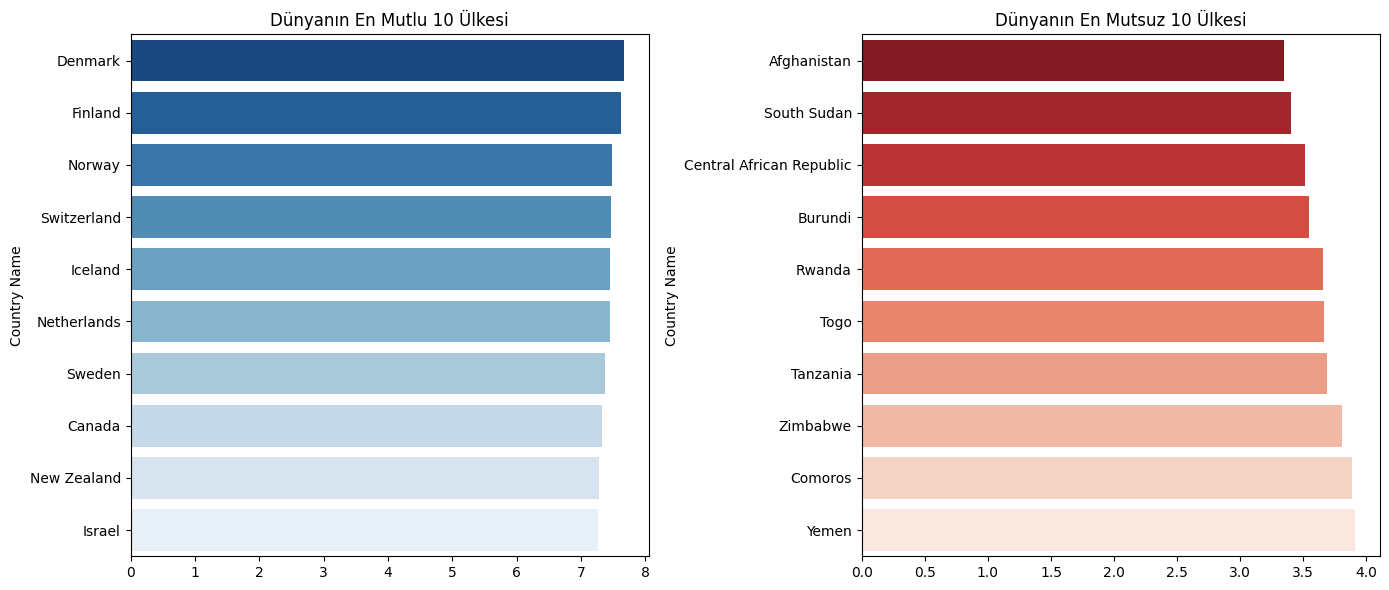

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# En mutlu 10 ülke
top_10 = df.groupby("Country Name")["Life Ladder"].mean().nlargest(10)

# En mutsuz 10 ülke
bottom_10 = df.groupby("Country Name")["Life Ladder"].mean().nsmallest(10)

# Çizim
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top_10.values, y=top_10.index, ax=axes[0], palette="Blues_r")
sns.barplot(x=bottom_10.values, y=bottom_10.index, ax=axes[1], palette="Reds_r")

# Başlıklar
axes[0].set_title("Dünyanın En Mutlu 10 Ülkesi")
axes[1].set_title("Dünyanın En Mutsuz 10 Ülkesi")

plt.tight_layout()
plt.show()


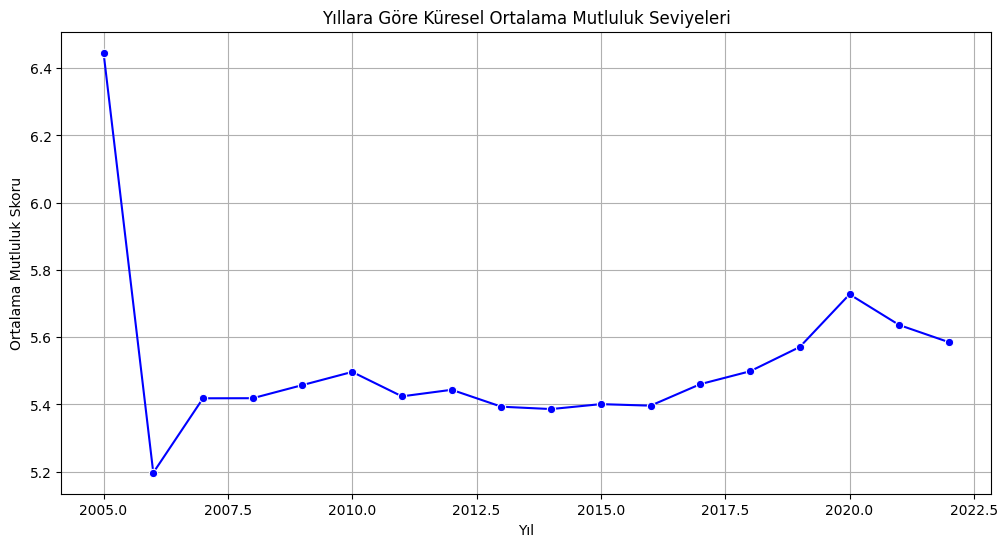

In [11]:
# Yıl bazında ortalama mutluluk
yearly_happiness = df.groupby("Year")["Life Ladder"].mean()

# Çizgi grafiği
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_happiness.index, y=yearly_happiness.values, marker="o", linestyle="-", color="b")
plt.title("Yıllara Göre Küresel Ortalama Mutluluk Seviyeleri")
plt.xlabel("Yıl")
plt.ylabel("Ortalama Mutluluk Skoru")
plt.grid()
plt.show()


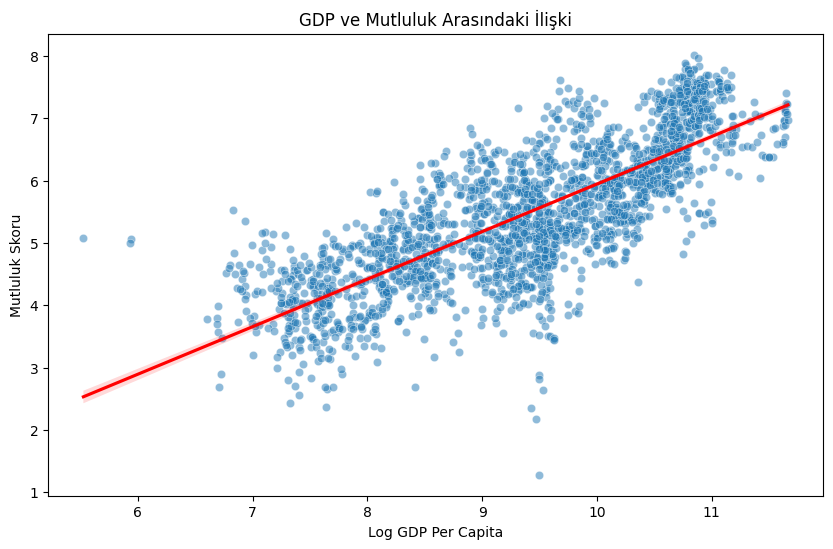

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Log GDP Per Capita"], y=df["Life Ladder"], alpha=0.5)
sns.regplot(x=df["Log GDP Per Capita"], y=df["Life Ladder"], scatter=False, color="red")
plt.title("GDP ve Mutluluk Arasındaki İlişki")
plt.xlabel("Log GDP Per Capita")
plt.ylabel("Mutluluk Skoru")
plt.show()


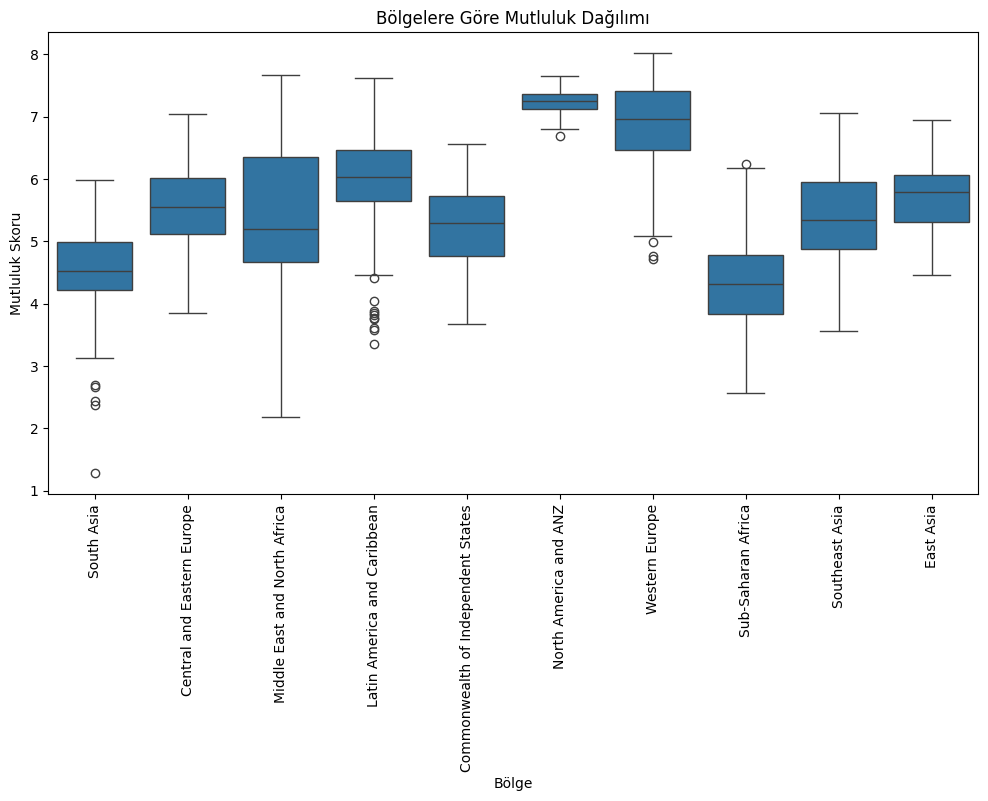

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df["Regional Indicator"], y=df["Life Ladder"])
plt.xticks(rotation=90)
plt.title("Bölgelere Göre Mutluluk Dağılımı")
plt.xlabel("Bölge")
plt.ylabel("Mutluluk Skoru")
plt.show()


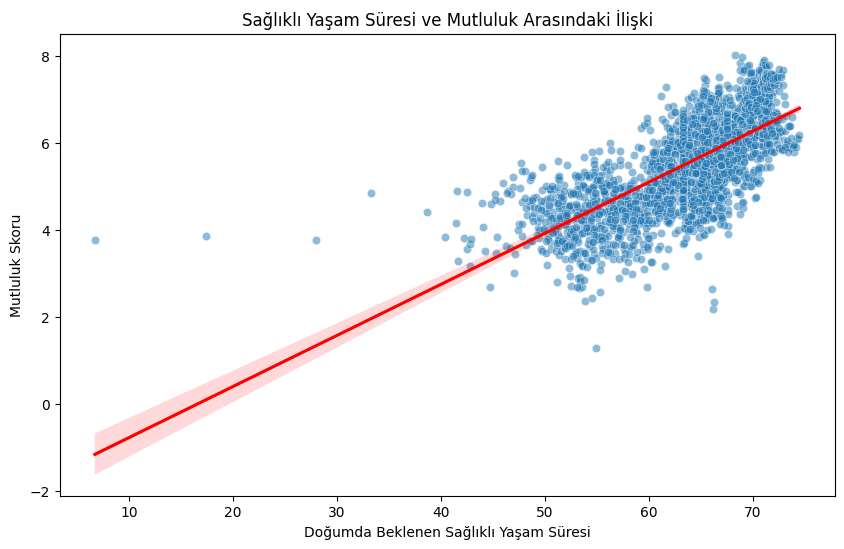

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Healthy Life Expectancy At Birth"], y=df["Life Ladder"], alpha=0.5)
sns.regplot(x=df["Healthy Life Expectancy At Birth"], y=df["Life Ladder"], scatter=False, color="red")
plt.title("Sağlıklı Yaşam Süresi ve Mutluluk Arasındaki İlişki")
plt.xlabel("Doğumda Beklenen Sağlıklı Yaşam Süresi")
plt.ylabel("Mutluluk Skoru")
plt.show()


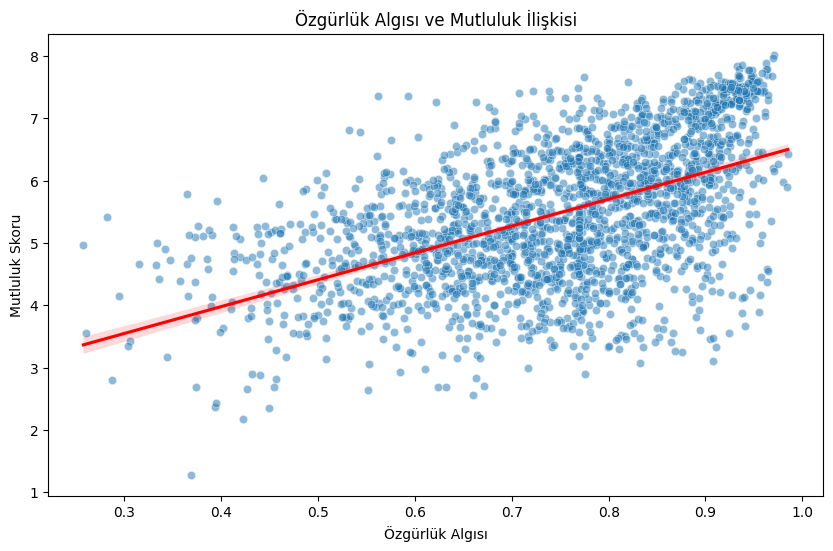

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Freedom To Make Life Choices"], y=df["Life Ladder"], alpha=0.5)
sns.regplot(x=df["Freedom To Make Life Choices"], y=df["Life Ladder"], scatter=False, color="red")
plt.title("Özgürlük Algısı ve Mutluluk İlişkisi")
plt.xlabel("Özgürlük Algısı")
plt.ylabel("Mutluluk Skoru")
plt.show()


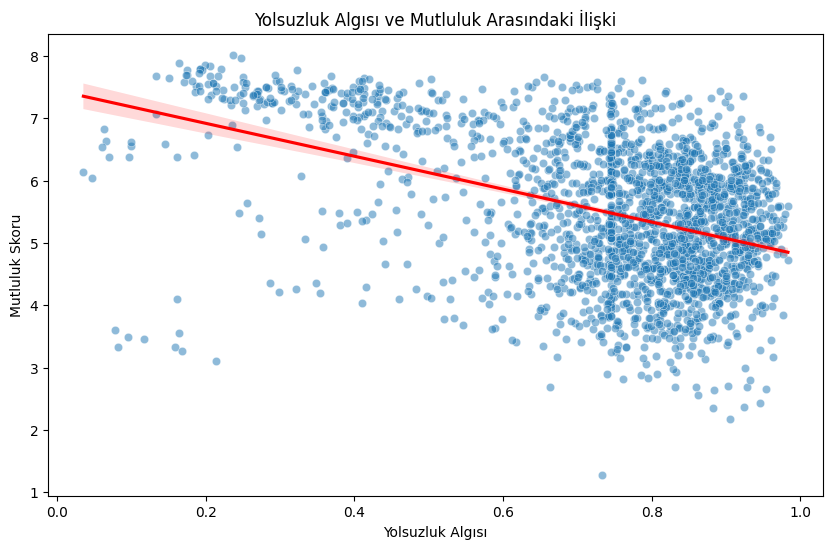

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Perceptions Of Corruption"], y=df["Life Ladder"], alpha=0.5)
sns.regplot(x=df["Perceptions Of Corruption"], y=df["Life Ladder"], scatter=False, color="red")
plt.title("Yolsuzluk Algısı ve Mutluluk Arasındaki İlişki")
plt.xlabel("Yolsuzluk Algısı")
plt.ylabel("Mutluluk Skoru")
plt.show()


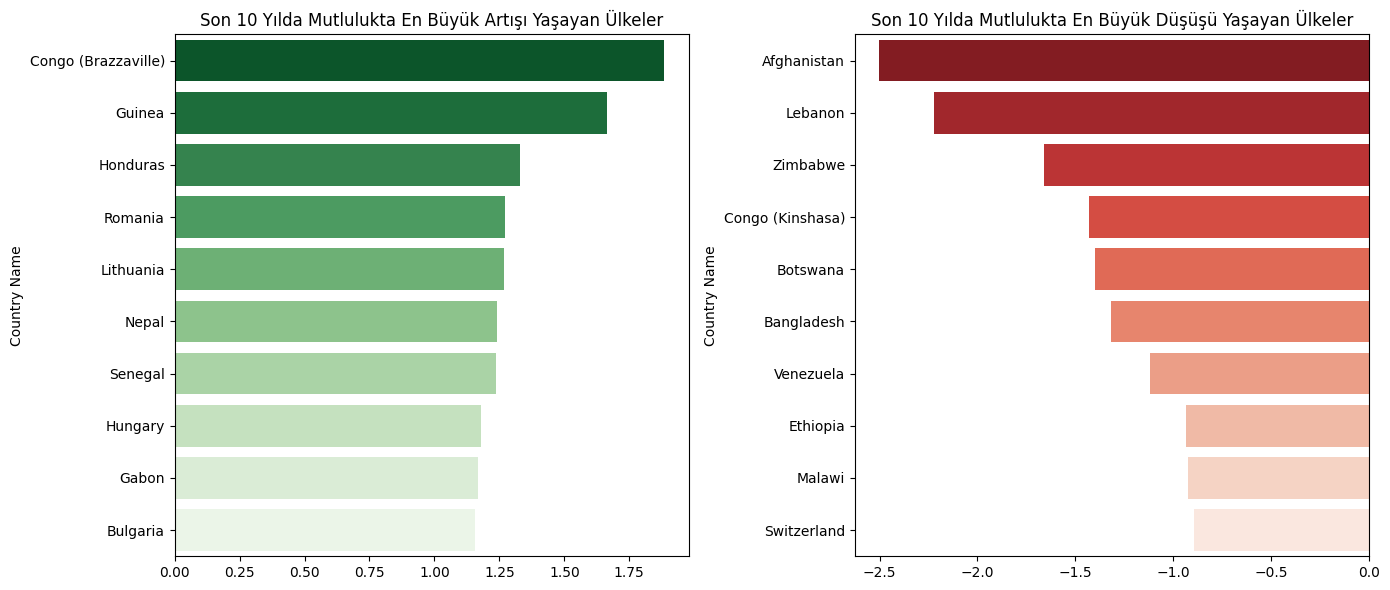

In [17]:
# 2012 ve 2022 yılları arasındaki değişimi hesapla
happiness_change = df[df["Year"].isin([2012, 2022])].pivot(index="Country Name", columns="Year", values="Life Ladder")
happiness_change["Change"] = happiness_change[2022] - happiness_change[2012]

# En büyük artış ve azalış gösteren 10 ülke
top_increase = happiness_change["Change"].nlargest(10)
top_decrease = happiness_change["Change"].nsmallest(10)

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top_increase.values, y=top_increase.index, ax=axes[0], palette="Greens_r")
sns.barplot(x=top_decrease.values, y=top_decrease.index, ax=axes[1], palette="Reds_r")

# Başlıklar
axes[0].set_title("Son 10 Yılda Mutlulukta En Büyük Artışı Yaşayan Ülkeler")
axes[1].set_title("Son 10 Yılda Mutlulukta En Büyük Düşüşü Yaşayan Ülkeler")

plt.tight_layout()
plt.show()


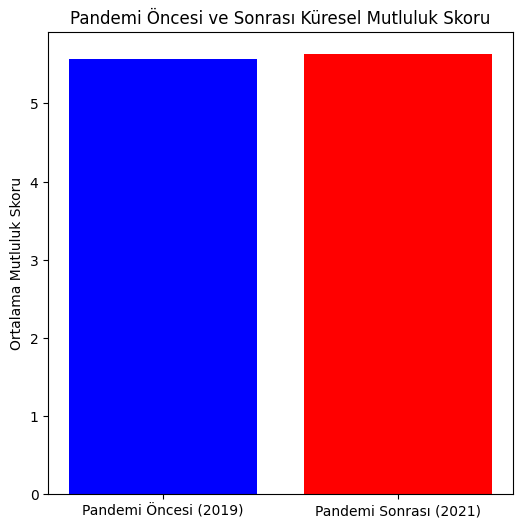

''

In [18]:
# Pandemi öncesi (2019) ve sonrası (2021) mutluluk ortalamaları
pre_pandemic = df[df["Year"] == 2019]["Life Ladder"].mean()
post_pandemic = df[df["Year"] == 2021]["Life Ladder"].mean()

# Bar grafiği
plt.figure(figsize=(6, 6))
plt.bar(["Pandemi Öncesi (2019)", "Pandemi Sonrası (2021)"], [pre_pandemic, post_pandemic], color=["blue", "red"])
plt.ylabel("Ortalama Mutluluk Skoru")
plt.title("Pandemi Öncesi ve Sonrası Küresel Mutluluk Skoru")
plt.show()
;

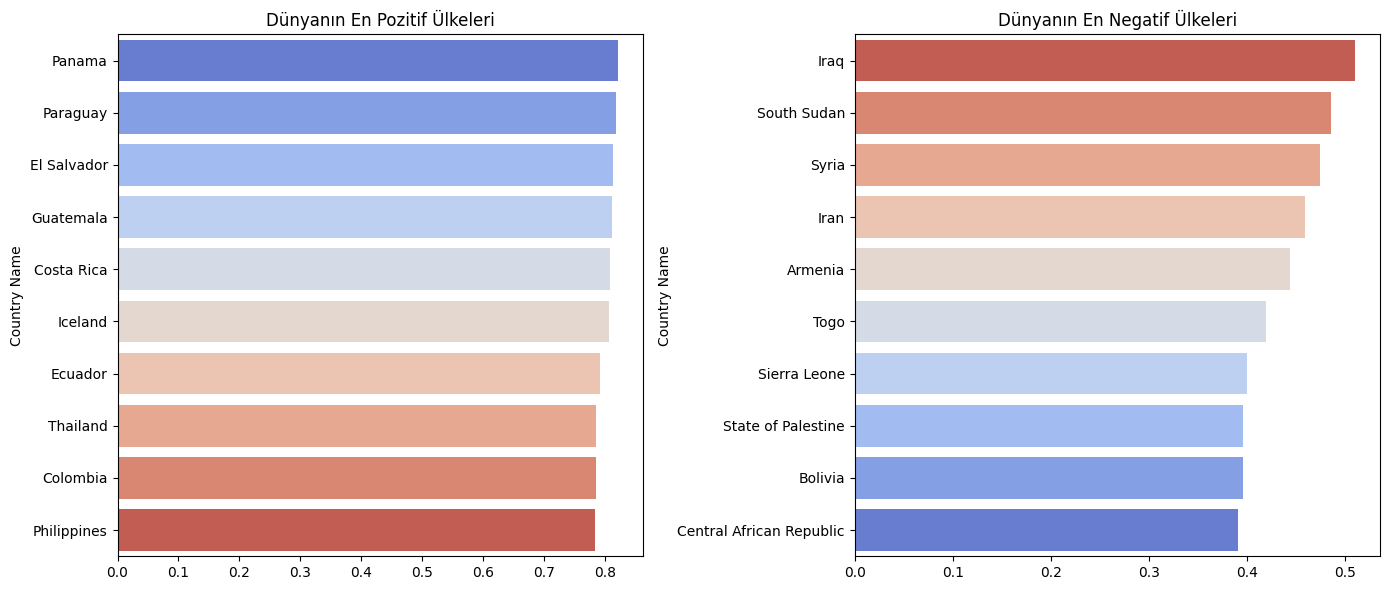

In [19]:
# En pozitif ülkeler (Positive Affect)
top_positive = df.groupby("Country Name")["Positive Affect"].mean().nlargest(10)

# En negatif ülkeler (Negative Affect)
top_negative = df.groupby("Country Name")["Negative Affect"].mean().nlargest(10)

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top_positive.values, y=top_positive.index, ax=axes[0], palette="coolwarm")
sns.barplot(x=top_negative.values, y=top_negative.index, ax=axes[1], palette="coolwarm_r")

axes[0].set_title("Dünyanın En Pozitif Ülkeleri")
axes[1].set_title("Dünyanın En Negatif Ülkeleri")

plt.tight_layout()
plt.show()


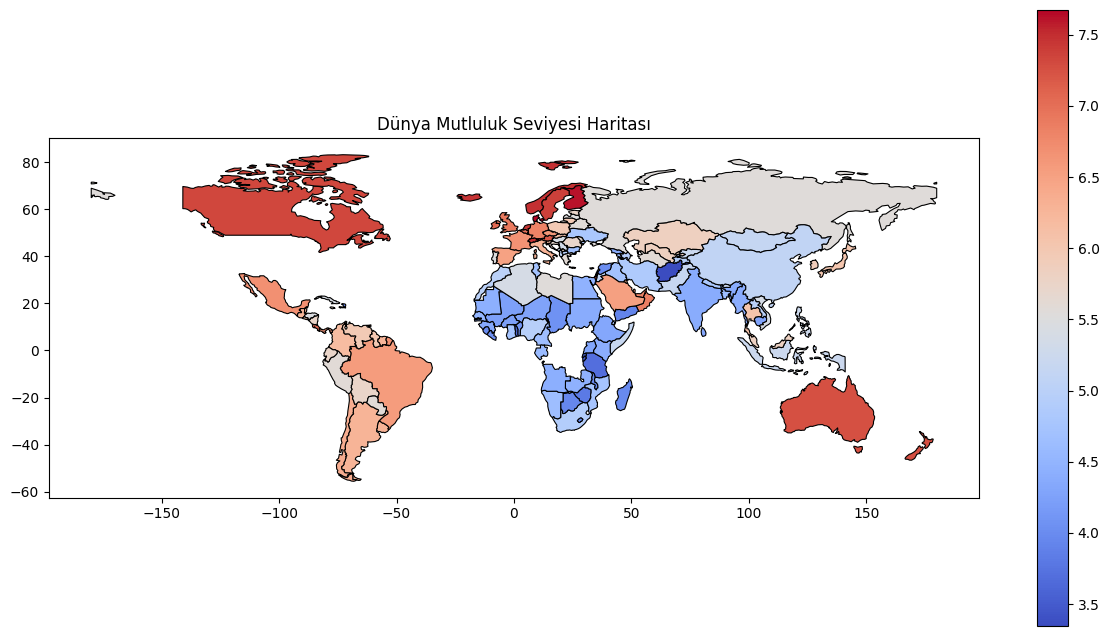

In [20]:
import geopandas as gpd

# Doğru Natural Earth veri setini indirerek yükle
world = gpd.read_file("https://github.com/nvkelso/natural-earth-vector/raw/master/geojson/ne_110m_admin_0_countries.geojson")

# Ülke bazında mutluluk ortalamalarını ekleyelim
happiness_map = df.groupby("Country Name")["Life Ladder"].mean().reset_index()
happiness_map.columns = ["name", "Happiness Score"]

# Harita ile birleştir
world = world.merge(happiness_map, left_on="NAME", right_on="name", how="left")

# Harita çizimi
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world.plot(column="Happiness Score", cmap="coolwarm", linewidth=0.8, edgecolor="black", legend=True, ax=ax)
plt.title("Dünya Mutluluk Seviyesi Haritası")
plt.show()


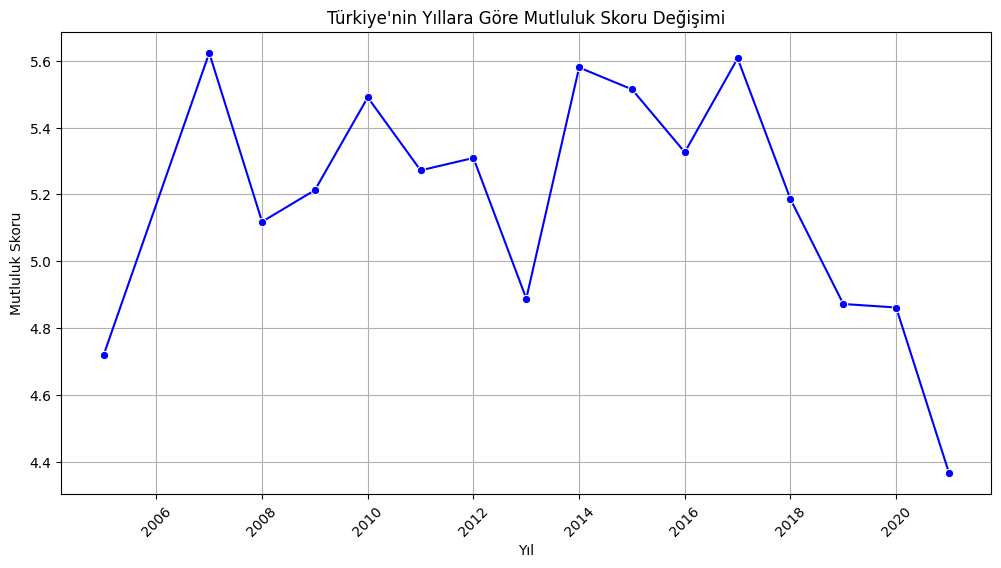

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Türkiye'nin yıllara göre mutluluk skorlarını filtreleyelim
turkey_data = df[df["Country Name"] == "Turkiye"]

# Çizgi grafiği
plt.figure(figsize=(12, 6))
sns.lineplot(x=turkey_data["Year"], y=turkey_data["Life Ladder"], marker="o", linestyle="-", color="b")

# Başlık ve etiketler
plt.title("Türkiye'nin Yıllara Göre Mutluluk Skoru Değişimi")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru")
plt.xticks(rotation=45)
plt.grid()

# Grafiği göster
plt.show()


In [22]:
import pandas as pd

# Türkiye'nin verisini alalım
turkey_data = df[df["Country Name"] == "Turkiye"].copy()

# Yıl sütununu indeks olarak ayarla
turkey_data.set_index("Year", inplace=True)

# Sadece mutluluk skoru olan sütunu kullan
turkey_series = turkey_data["Life Ladder"]

# Verinin son halini göster
print(turkey_series)


Year
2005    4.718734
2007    5.623472
2008    5.118232
2009    5.212842
2010    5.490347
2011    5.271944
2012    5.309076
2013    4.888177
2014    5.579794
2015    5.514465
2016    5.326222
2017    5.607262
2018    5.185689
2019    4.872074
2020    4.861554
2021    4.366640
Name: Life Ladder, dtype: float64


## Şimdi Zaman Serisi Analizi ile önümüzdeki 5 yıl içinde ne olacak bakalım..

In [23]:
#önce veriyi düzenleyelim

In [24]:
# 1. Veriseti (2007-2021)
data1 = {
    "Country Name": ["Turkiye"] * 15,
    "Year": list(range(2007, 2022)),
    "Life Ladder": [5.623471737, 5.118231773, 5.212841511, 5.490347385, 5.271944046, 5.309076309, 
                    4.888177395, 5.579794407, 5.514465332, 5.326221943, 5.607262135, 5.185689449, 4.87207365, 
                    4.861554146, 4.366639614],
    "Log GDP Per Capita": [9.89130497, 9.887406349, 9.825364113, 9.892935753, 9.985816956, 10.01782227, 
                           10.08216667, 10.11052322, 10.15013885, 10.16573524, 10.22494888, 10.2455864, 10.24530506, 
                           10.25671864, 10.35668087],
    "Social Support": [0.792272806, 0.644873619, 0.754645526, 0.794905484, 0.691901684, 0.739280581, 
                       0.795451164, 0.863288283, 0.851224601, 0.879994631, 0.876467824, 0.847027302, 0.791656196, 
                       0.856730223, 0.736194909],
    "Healthy Life Expectancy At Birth": [66.41999817, 66.58000183, 66.73999786, 66.90000153, 67.05999756, 
                                         67.22000122, 67.37999725, 67.54000092, 67.69999695, 67.875, 68.05000305, 
                                         68.22499847, 68.40000153, 68.57499695, 68.75],
    "Freedom To Make Life Choices": [0.459311515, 0.415497869, 0.455817074, 0.514920354, 0.445606649, 
                                     0.470903218, 0.540723383, 0.649196088, 0.653196752, 0.64414674, 0.644434214, 
                                     0.528629065, 0.631083786, 0.510385871, 0.44652763],
    "Generosity": [-0.180983201, -0.191523522, -0.229694709, -0.189835683, -0.244793341, -0.218662322, -0.23243539, 
                   -0.026465939, -0.018882724, -0.067680292, -0.240131393, -0.179061726, -0.139380321, -0.117426276, -0.036791019],
    "Perceptions Of Corruption": [0.799733341, 0.785390556, 0.852887154, 0.810895741, 0.648596227, 
                                  0.701850235, 0.698064804, 0.764013529, 0.806076229, 0.763706565, 0.670910537, 
                                  0.804878533, 0.760442197, 0.774417162, 0.810165942]
}

# 2. Veriseti (2022)
data2 = {
    "Country Name": ["Turkiye"],
    "Year": [2022],
    "Life Ladder": [4.744],
    "Log GDP Per Capita": [1.707],
    "Social Support": [0.865],
    "Healthy Life Expectancy At Birth": [0.702],
    "Freedom To Make Life Choices": [0.209],
    "Generosity": [0.087],
    "Perceptions Of Corruption": [0.115]
}

# 3. Veriseti (2023)
data3 = {
    "Country Name": ["Turkiye"],
    "Year": [2023],
    "Life Ladder": [4.614],
    "Log GDP Per Capita": [10.307],
    "Social Support": [0.796],
    "Healthy Life Expectancy At Birth": [68.663],
    "Freedom To Make Life Choices": [0.475],
    "Generosity": [-0.077],
    "Perceptions Of Corruption": [0.795]
}

# 4. Veriseti (2024)
data4 = {
    "Country Name": ["Turkiye"],
    "Year": [2024],
    "Life Ladder": [4.975],
    "Log GDP Per Capita": [1.702],
    "Social Support": [1.175],
    "Healthy Life Expectancy At Birth": [0.631],
    "Freedom To Make Life Choices": [0.202],
    "Generosity": [0.068],
    "Perceptions Of Corruption": [0.115]
}

# DataFrame'leri birleştirme
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
df3 = pd.DataFrame(data3)
df4 = pd.DataFrame(data4)

# Tüm yılları içeren nihai veri seti
final_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

final_df

,Country Name,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption
0,Turkiye,2007,5.623472,9.891305,0.792273,66.419998,0.459312,-0.180983,0.799733
1,Turkiye,2008,5.118232,9.887406,0.644874,66.580002,0.415498,-0.191524,0.785391
2,Turkiye,2009,5.212842,9.825364,0.754646,66.739998,0.455817,-0.229695,0.852887
3,Turkiye,2010,5.490347,9.892936,0.794905,66.900002,0.514920,-0.189836,0.810896
4,Turkiye,2011,5.271944,9.985817,0.691902,67.059998,0.445607,-0.244793,0.648596
5,Turkiye,2012,5.309076,10.017822,0.739281,67.220001,0.470903,-0.218662,0.701850
6,Turkiye,2013,4.888177,10.082167,0.795451,67.379997,0.540723,-0.232435,0.698065
7,Turkiye,2014,5.579794,10.110523,0.863288,67.540001,0.649196,-0.026466,0.764014
8,Turkiye,2015,5.514465,10.150139,0.851225,67.699997,0.653197,-0.018883,0.806076
9,Turkiye,2016,5.326222,10.165735,0.879995,67.875000,0.644147,-0.067680,0.763707


In [25]:
final_df.to_csv('mutluluk_verisi.csv', index=False)

In [26]:
df = pd.read_csv("mutluluk_verisi.csv")  # CSV dosya adını güncelle
df["Year"] = pd.to_datetime(df["Year"], format="%Y")  # Yılı datetime formatına çevir
df.set_index("Year", inplace=True)  # Yılı indeks yap

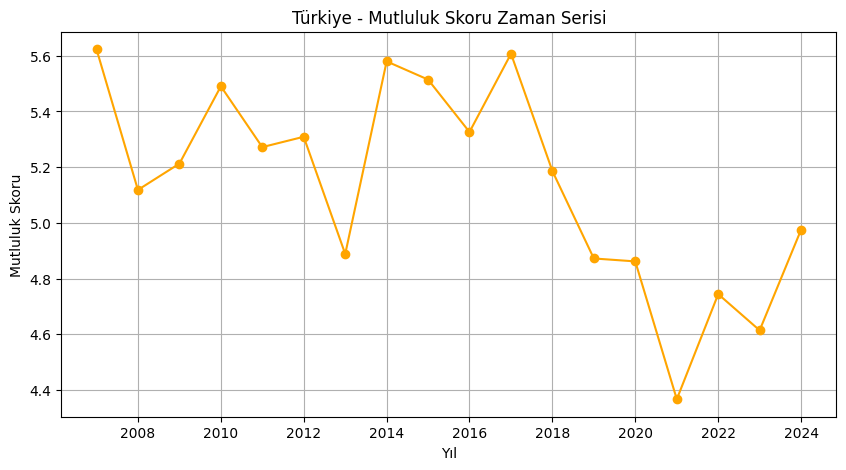

In [27]:
# ---------------- ZAMAN SERİSİ GÖRSELLEŞTİRME ----------------
def plot_time_series(data, y_col, title, ylabel, color="blue"):
    plt.figure(figsize=(10, 5))
    plt.plot(data.index, data[y_col], marker="o", linestyle="-", color=color)
    plt.xlabel("Yıl")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

# Grafikleri çizdirme
plot_time_series(df, "Life Ladder", "Türkiye - Mutluluk Skoru Zaman Serisi", "Mutluluk Skoru", "orange")

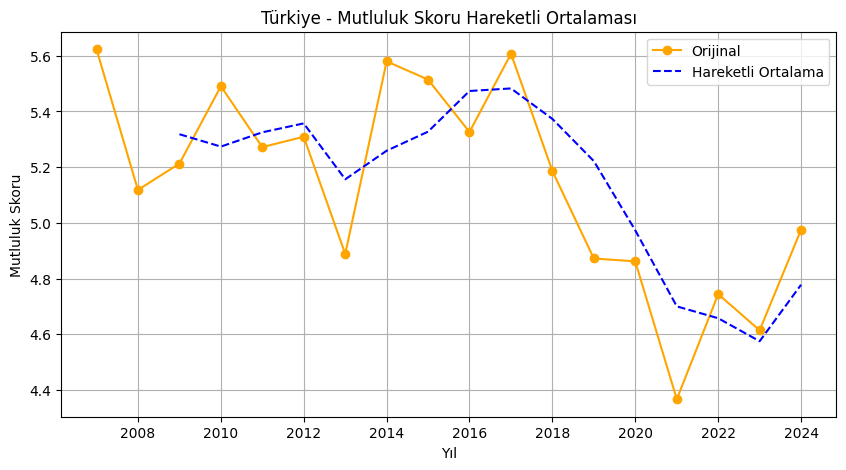

In [28]:
# ---------------- HAREKETLİ ORTALAMA TREND ANALİZİ ----------------
df["Life Ladder MA"] = df["Life Ladder"].rolling(window=3).mean()  # 3 yıllık hareketli ortalama
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Life Ladder"], marker="o", linestyle="-", label="Orijinal", color="orange")
plt.plot(df.index, df["Life Ladder MA"], linestyle="--", label="Hareketli Ortalama", color="blue")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru")
plt.title("Türkiye - Mutluluk Skoru Hareketli Ortalaması")
plt.legend()
plt.grid(True)
plt.show()


16:24:38 - cmdstanpy - INFO - Chain [1] start processing
16:24:39 - cmdstanpy - INFO - Chain [1] done processing


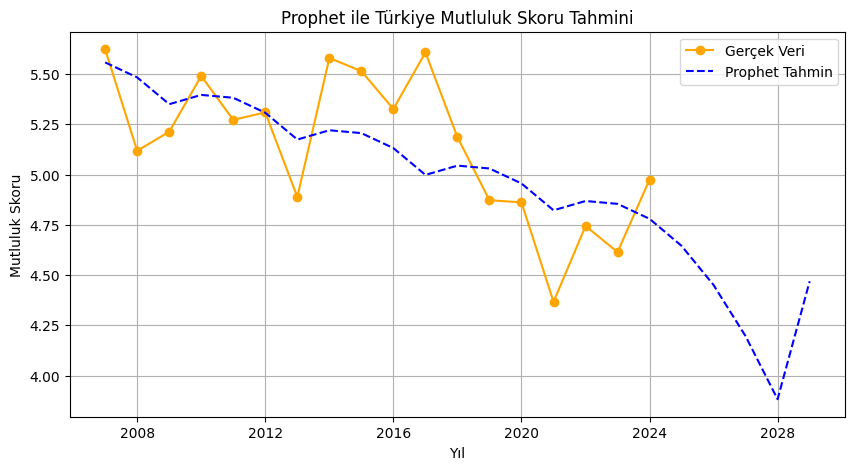

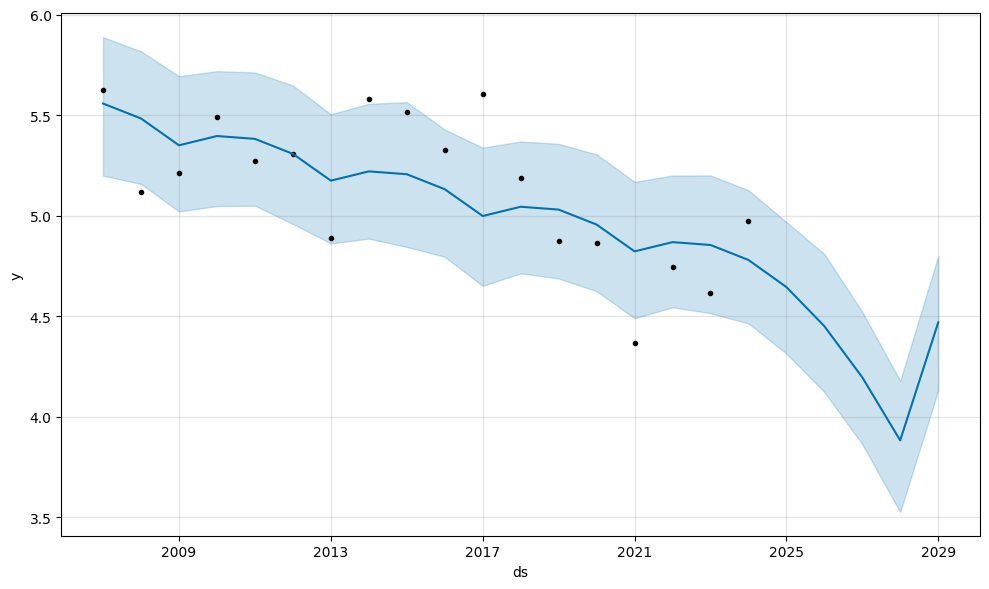

In [29]:
# ---------------- PROPHET MODELİ İLE TAHMİN ----------------
df_prophet = df.reset_index()[["Year", "Life Ladder"]].dropna()
df_prophet.columns = ["ds", "y"]  # Prophet için uygun isimlendirme

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=5, freq="Y")  # 5 yıl ileri tahmin
forecast = prophet_model.predict(future)

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Life Ladder"], marker="o", linestyle="-", label="Gerçek Veri", color="orange")
plt.plot(forecast["ds"], forecast["yhat"], linestyle="--", label="Prophet Tahmin", color="blue")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru")
plt.title("Prophet ile Türkiye Mutluluk Skoru Tahmini")
plt.legend()
plt.grid(True)
plt.show()

# Prophet'in detaylı tahmin çıktısını görmek için:
prophet_model.plot(forecast)
plt.show()

📌 En iyi ARIMA parametreleri: (1, 1, 0)


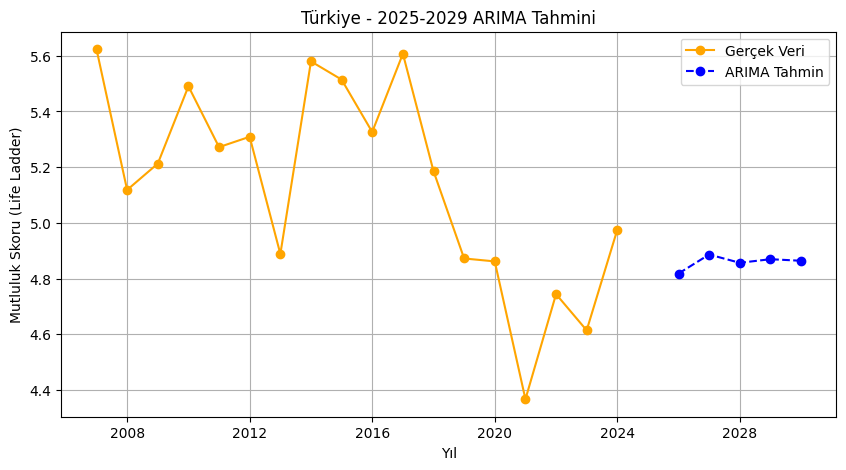

            Life Ladder Prediction
Year                              
2025-12-31                4.817890
2026-12-31                4.886265
2027-12-31                4.856508
2028-12-31                4.869459
2029-12-31                4.863822


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")  # Uyarıları kapat

# ---------------- VERİYİ YÜKLEME VE HAZIRLAMA ----------------
df = pd.read_csv("mutluluk_verisi.csv")  # CSV dosya adını değiştir
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df.set_index("Year", inplace=True)

# ARIMA için mutluluk skorunu kullanacağız
series = df["Life Ladder"].dropna()

# ---------------- EN İYİ ARIMA PARAMETRELERİNİ BELİRLEME ----------------
p = d = q = range(0, 3)  # p, d, q için 0 ile 2 arasında değerler deneyeceğiz
pdq_combinations = list(itertools.product(p, d, q))

best_aic = float("inf")
best_pdq = None
best_model = None

for param in pdq_combinations:
    try:
        model = ARIMA(series, order=param)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_pdq = param
            best_model = results
    except:
        continue

print(f"📌 En iyi ARIMA parametreleri: {best_pdq}")

# ---------------- EN İYİ MODEL İLE TAHMİN YAPMA ----------------
future_years = pd.date_range(start="2025", periods=5, freq="Y")  # 2025-2029
forecast_values = best_model.forecast(steps=5)

# Tahminleri DataFrame'e ekleyelim
forecast_df = pd.DataFrame({"Year": future_years, "Life Ladder Prediction": forecast_values})
forecast_df.set_index("Year", inplace=True)

# ---------------- TAHMİNİ GÖRSELLEŞTİRME ----------------
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Life Ladder"], marker="o", linestyle="-", label="Gerçek Veri", color="orange")
plt.plot(forecast_df.index, forecast_df["Life Ladder Prediction"], marker="o", linestyle="--", label="ARIMA Tahmin", color="blue")

plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru (Life Ladder)")
plt.title("Türkiye - 2025-2029 ARIMA Tahmini")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- TAHMİN SONUÇLARINI GÖSTERME ----------------
print(forecast_df)


16:24:43 - cmdstanpy - INFO - Chain [1] start processing
16:24:43 - cmdstanpy - INFO - Chain [1] done processing


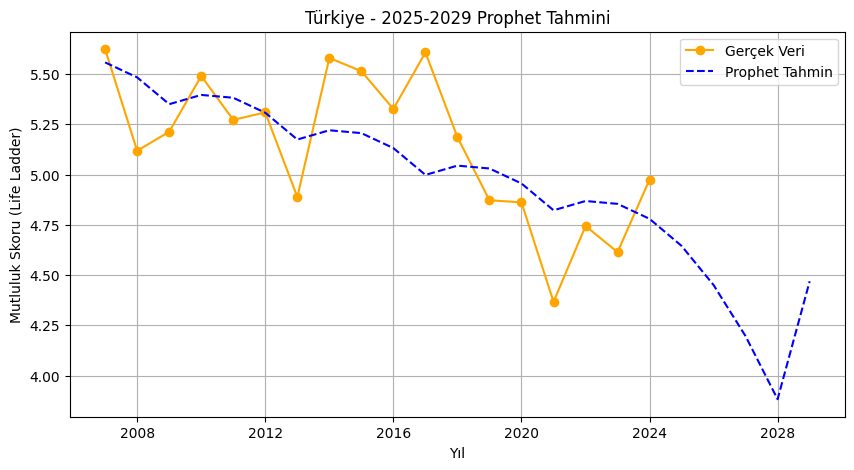

           ds      yhat  yhat_lower  yhat_upper
19 2025-12-31  4.450275    4.122965    4.806351
20 2026-12-31  4.195850    3.858437    4.540989
21 2027-12-31  3.882065    3.544729    4.259134
22 2028-12-31  4.468939    4.122321    4.799066


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# ---------------- VERİYİ YÜKLEME VE HAZIRLAMA ----------------
df = pd.read_csv("mutluluk_verisi.csv")  # Dosya adını değiştir
df["Year"] = pd.to_datetime(df["Year"], format="%Y")

# Prophet modeli için uygun sütun isimlendirme
df_prophet = df[["Year", "Life Ladder"]].dropna()
df_prophet.columns = ["ds", "y"]  # Prophet için "ds" (tarih) ve "y" (hedef değişken) gerekiyor

# Prophet Modelini Eğitme
prophet_model = Prophet()
prophet_model.fit(df_prophet)

# ---------------- GELECEK 5 YILLIK TAHMİN ----------------
future = prophet_model.make_future_dataframe(periods=5, freq="Y")  # 2025-2029 tahmini
forecast = prophet_model.predict(future)

# ---------------- GRAFİKLEME ----------------
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Life Ladder"], marker="o", linestyle="-", label="Gerçek Veri", color="orange")
plt.plot(forecast["ds"], forecast["yhat"], linestyle="--", label="Prophet Tahmin", color="blue")

plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru (Life Ladder)")
plt.title("Türkiye - 2025-2029 Prophet Tahmini")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- TAHMİN SONUÇLARINI GÖSTERME ----------------
forecast_future = forecast[forecast["ds"] >= "2025"][["ds", "yhat", "yhat_lower", "yhat_upper"]]
print(forecast_future)


In [32]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv("mutluluk_verisi.csv")  # Sizin CSV dosyanız
df["Year"] = pd.to_datetime(df["Year"], format="%Y")  # Yılı datetime formatına çevir
df.set_index("Year", inplace=True)                   # Yılı indeks yap

print("Veri Seti Boyutu   :", df.shape)
print("Veri Setinin İlk Satırları:\n", df.head(), "\n")

# -------------------------------------------------
# 2) EĞİTİM (TRAIN) ve TEST OLARAK BÖLME
# -------------------------------------------------
# Örnek olarak 2007–2018 train, 2019–2024 test
train = df.loc["2007":"2018"].copy()
test  = df.loc["2019":"2024"].copy()

# Prophet formatına dönüştür
df_prophet_train = train.reset_index()[["Year", "Life Ladder"]]
df_prophet_train.columns = ["ds", "y"]

# Prophet modeli eğitimi
prophet_model = Prophet()
prophet_model.fit(df_prophet_train)

# Test verisi 6 yıl: 2019–2024 => periods = 7 (fazladan 1 yıl ekle)
future = prophet_model.make_future_dataframe(periods=7, freq="Y")
forecast = prophet_model.predict(future)

# 2019–2024 aralığını filtrele (6 yıl)
forecast_test = forecast[(forecast["ds"] >= "2019-01-01") & (forecast["ds"] <= "2024-12-31")]

# Gerçek ve tahmin değerleri
y_true = test["Life Ladder"].values
y_pred_prophet = forecast_test["yhat"].values

# Kontrol: Boyutlar eşit mi?
print("✅ y_true:", len(y_true), "y_pred_prophet:", len(y_pred_prophet))  # ikisi de 6 olmalı

# Performans metrikleri
mae_prophet = mean_absolute_error(y_true, y_pred_prophet)
mse_prophet = mean_squared_error(y_true, y_pred_prophet)
rmse_prophet = np.sqrt(mse_prophet)
mape_prophet = np.mean(np.abs((y_true - y_pred_prophet) / y_true)) * 100

print("✅ Prophet Performans (2019–2024)")
print(f"MAE  : {mae_prophet:.3f}")
print(f"RMSE : {rmse_prophet:.3f}")
print(f"MAPE : {mape_prophet:.2f}%")


16:24:44 - cmdstanpy - INFO - Chain [1] start processing
16:24:44 - cmdstanpy - INFO - Chain [1] done processing


Veri Seti Boyutu   : (18, 8)
Veri Setinin İlk Satırları:
            Country Name  Life Ladder  Log GDP Per Capita  Social Support  \
Year                                                                       
2007-01-01      Turkiye     5.623472            9.891305        0.792273   
2008-01-01      Turkiye     5.118232            9.887406        0.644874   
2009-01-01      Turkiye     5.212842            9.825364        0.754646   
2010-01-01      Turkiye     5.490347            9.892936        0.794905   
2011-01-01      Turkiye     5.271944            9.985817        0.691902   

            Healthy Life Expectancy At Birth  Freedom To Make Life Choices  \
Year                                                                         
2007-01-01                         66.419998                      0.459312   
2008-01-01                         66.580002                      0.415498   
2009-01-01                         66.739998                      0.455817   
2010-01-01         

In [33]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# ARIMA modeli (örnek: ARIMA(1,1,1))
arima_model = ARIMA(train["Life Ladder"], order=(1, 1, 1))
arima_result = arima_model.fit()

# 6 yıl ileri tahmin (2019–2024)
forecast_arima = arima_result.forecast(steps=6)

# Gerçek ve tahmin değerleri
y_pred_arima = forecast_arima.values
y_true = test["Life Ladder"].values

# Performans metrikleri
mae_arima = mean_absolute_error(y_true, y_pred_arima)
mse_arima = mean_squared_error(y_true, y_pred_arima)
rmse_arima = np.sqrt(mse_arima)
mape_arima = np.mean(np.abs((y_true - y_pred_arima) / y_true)) * 100

print("✅ ARIMA Performans (2019–2024)")
print(f"MAE  : {mae_arima:.3f}")
print(f"RMSE : {rmse_arima:.3f}")
print(f"MAPE : {mape_arima:.2f}%")


✅ ARIMA Performans (2019–2024)
MAE  : 0.608
RMSE : 0.640
MAPE : 13.04%


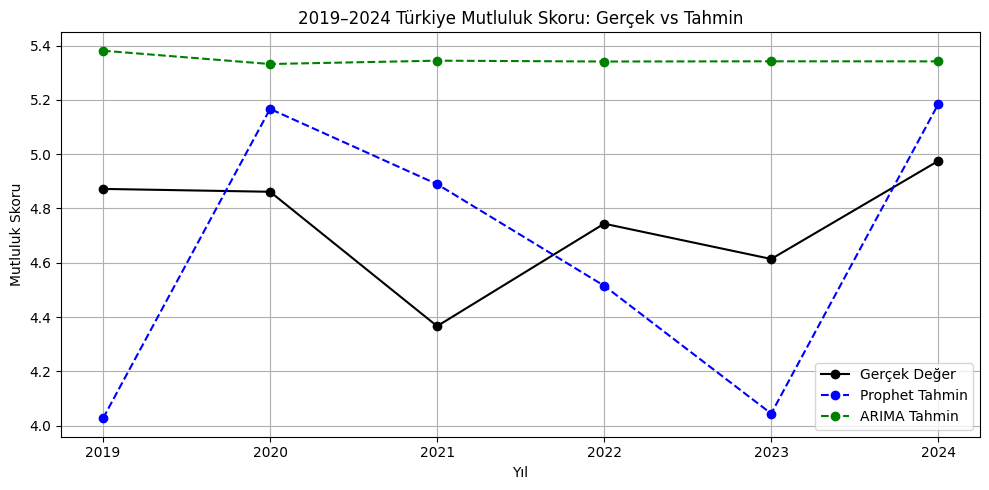

In [34]:
years = test.index.year

plt.figure(figsize=(10, 5))
plt.plot(years, y_true, marker='o', label='Gerçek Değer', color='black')
plt.plot(years, y_pred_prophet, marker='o', linestyle='--', label='Prophet Tahmin', color='blue')
plt.plot(years, y_pred_arima, marker='o', linestyle='--', label='ARIMA Tahmin', color='green')

plt.title("2019–2024 Türkiye Mutluluk Skoru: Gerçek vs Tahmin")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Prophet modeli, RMSE, MAE ve MAPE açısından daha başarılı.

ARIMA, değerleri fazla sabit tuttuğu için değişimi iyi yansıtamamış.

Görsel olarak da Prophet, gerçek verilere daha yakın seyretti.

## Eğitim Seviyesine Göre Mutluluk Analizi

In [35]:
# CSV dosyasını yükleyelim
df_edu = pd.read_csv("egitim_mutluluk_cleaned.csv")

df_edu.head(50)

,Yıl,Mutlu - Bir okul bitirmedi,Mutlu - İlkokul,Mutlu - İlköğretim/Ortaokul,Mutlu - Lise,Mutlu - Yükseköğretim,Orta - Bir okul bitirmedi,Orta - İlkokul,Orta - İlköğretim/Ortaokul,Orta - Lise,Orta - Yükseköğretim,Mutsuz - Bir okul bitirmedi,Mutsuz - İlkokul,Mutsuz - İlköğretim/Ortaokul,Mutsuz - Lise,Mutsuz - Yükseköğretim
0,2004,54.4,57.7,58.3,58.2,66.8,27.0,30.7,31.3,31.4,25.6,18.6,11.6,10.4,10.4,7.7
1,2005,54.0,55.2,61.4,61.5,64.0,27.8,31.8,26.0,29.6,26.2,18.1,13.1,12.6,8.9,9.8
2,2006,55.1,57.5,53.9,59.3,68.4,27.8,30.6,34.1,31.3,26.3,17.1,11.9,12.1,9.4,5.4
3,2007,57.8,59.3,61.6,62.8,61.9,26.0,29.6,27.7,29.0,30.8,16.2,11.1,10.7,8.2,7.3
4,2008,55.8,54.0,55.3,55.5,62.9,26.3,31.8,31.7,33.1,24.6,17.8,14.2,12.9,11.4,12.5
5,2009,51.8,52.5,56.1,54.7,63.2,27.3,32.8,32.3,32.4,27.8,21.0,14.7,11.6,13.0,9.0
6,2010,56.3,60.5,61.6,62.7,67.7,28.9,29.0,27.6,27.1,26.2,14.8,10.6,10.8,10.1,6.1
7,2011,57.2,61.1,64.4,63.9,66.7,27.7,28.8,27.7,28.0,26.4,15.1,10.1,7.9,8.1,6.8
8,2012,55.0,60.0,60.2,63.6,67.4,30.8,30.0,28.1,28.2,25.6,14.2,10.1,11.6,8.2,7.0
9,2013,59.8,57.3,58.4,59.8,62.5,24.4,31.9,31.9,31.2,29.5,15.8,10.9,9.7,9.0,8.0


In [36]:
# Veri hakkında genel bilgi
df_edu.info()

# Temel istatistiksel özet
df_edu.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Yıl                           21 non-null     int64  
 1   Mutlu - Bir okul bitirmedi    21 non-null     float64
 2   Mutlu - İlkokul               21 non-null     float64
 3   Mutlu - İlköğretim/Ortaokul   21 non-null     float64
 4   Mutlu - Lise                  21 non-null     float64
 5   Mutlu - Yükseköğretim         21 non-null     float64
 6   Orta - Bir okul bitirmedi     21 non-null     float64
 7   Orta - İlkokul                21 non-null     float64
 8   Orta - İlköğretim/Ortaokul    21 non-null     float64
 9   Orta - Lise                   21 non-null     float64
 10  Orta - Yükseköğretim          21 non-null     float64
 11  Mutsuz - Bir okul bitirmedi   21 non-null     float64
 12  Mutsuz - İlkokul              21 non-null     float64
 13  Mutsuz 

,Yıl,Mutlu - Bir okul bitirmedi,Mutlu - İlkokul,Mutlu - İlköğretim/Ortaokul,Mutlu - Lise,Mutlu - Yükseköğretim,Orta - Bir okul bitirmedi,Orta - İlkokul,Orta - İlköğretim/Ortaokul,Orta - Lise,Orta - Yükseköğretim,Mutsuz - Bir okul bitirmedi,Mutsuz - İlkokul,Mutsuz - İlköğretim/Ortaokul,Mutsuz - Lise,Mutsuz - Yükseköğretim
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,2014.000000,56.190476,55.514286,55.552381,55.976190,58.909524,28.033333,31.814286,32.371429,32.795238,30.971429,15.766667,12.685714,12.061905,11.242857,10.128571
std,6.204837,3.165107,3.834356,5.628465,5.481141,7.342268,2.285680,2.284357,3.639937,3.351489,4.740374,2.269214,1.871172,2.561538,2.553541,3.138175
min,2004.000000,51.700000,49.400000,44.200000,46.800000,46.100000,23.500000,26.800000,26.000000,27.100000,24.600000,11.700000,10.100000,7.900000,8.100000,5.400000
25%,2009.000000,54.400000,52.500000,52.600000,51.300000,52.700000,27.000000,30.500000,29.600000,31.200000,26.300000,14.200000,11.100000,10.700000,9.400000,7.700000
50%,2014.000000,55.400000,54.800000,56.100000,56.500000,60.200000,27.800000,31.800000,32.300000,32.700000,30.300000,15.100000,12.600000,11.800000,10.500000,9.700000
75%,2019.000000,57.800000,57.700000,60.200000,59.800000,64.000000,29.200000,33.200000,35.100000,35.600000,35.200000,17.100000,14.100000,12.900000,13.000000,12.500000
max,2024.000000,63.500000,62.900000,64.400000,63.900000,68.400000,33.200000,35.600000,39.900000,39.100000,39.300000,21.000000,15.900000,18.400000,16.600000,17.200000


In [37]:
# Eksik veri kontrolü
missing_values = df_edu.isnull().sum()
print(missing_values)

Yıl                             0
Mutlu - Bir okul bitirmedi      0
Mutlu - İlkokul                 0
Mutlu - İlköğretim/Ortaokul     0
Mutlu - Lise                    0
Mutlu - Yükseköğretim           0
Orta - Bir okul bitirmedi       0
Orta - İlkokul                  0
Orta - İlköğretim/Ortaokul      0
Orta - Lise                     0
Orta - Yükseköğretim            0
Mutsuz - Bir okul bitirmedi     0
Mutsuz - İlkokul                0
Mutsuz - İlköğretim/Ortaokul    0
Mutsuz - Lise                   0
Mutsuz - Yükseköğretim          0
dtype: int64


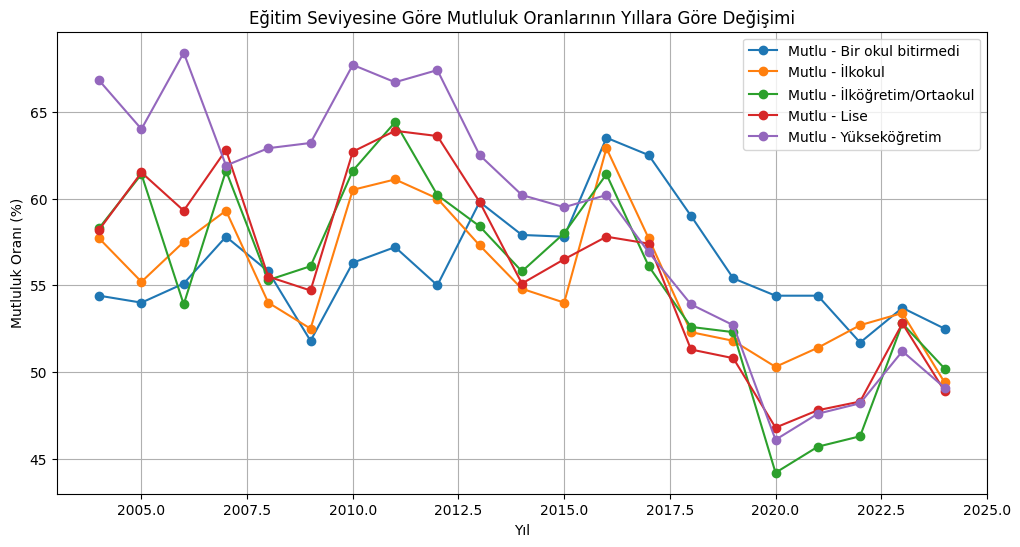

In [38]:
plt.figure(figsize=(12,6))

# Yıllara göre değişimi çizelim
for column in df_edu.columns[1:6]:  # Sadece "Mutlu" kategorilerini alıyoruz
    plt.plot(df_edu["Yıl"], df_edu[column], marker="o", label=column)

plt.xlabel("Yıl")
plt.ylabel("Mutluluk Oranı (%)")
plt.title("Eğitim Seviyesine Göre Mutluluk Oranlarının Yıllara Göre Değişimi")
plt.legend()
plt.grid()
plt.show()

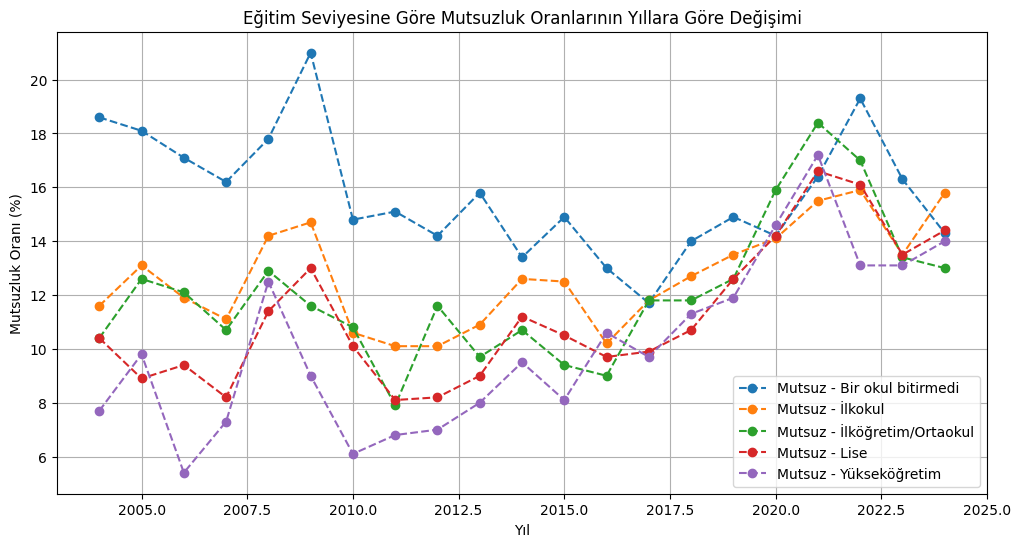

In [39]:
plt.figure(figsize=(12,6))

# Mutsuz olan grupları çizelim
for column in df_edu.columns[-5:]:
    plt.plot(df_edu["Yıl"], df_edu[column], marker="o", linestyle="dashed", label=column)

plt.xlabel("Yıl")
plt.ylabel("Mutsuzluk Oranı (%)")
plt.title("Eğitim Seviyesine Göre Mutsuzluk Oranlarının Yıllara Göre Değişimi")
plt.legend()
plt.grid()
plt.show()


16:24:46 - cmdstanpy - INFO - Chain [1] start processing
16:24:46 - cmdstanpy - INFO - Chain [1] done processing


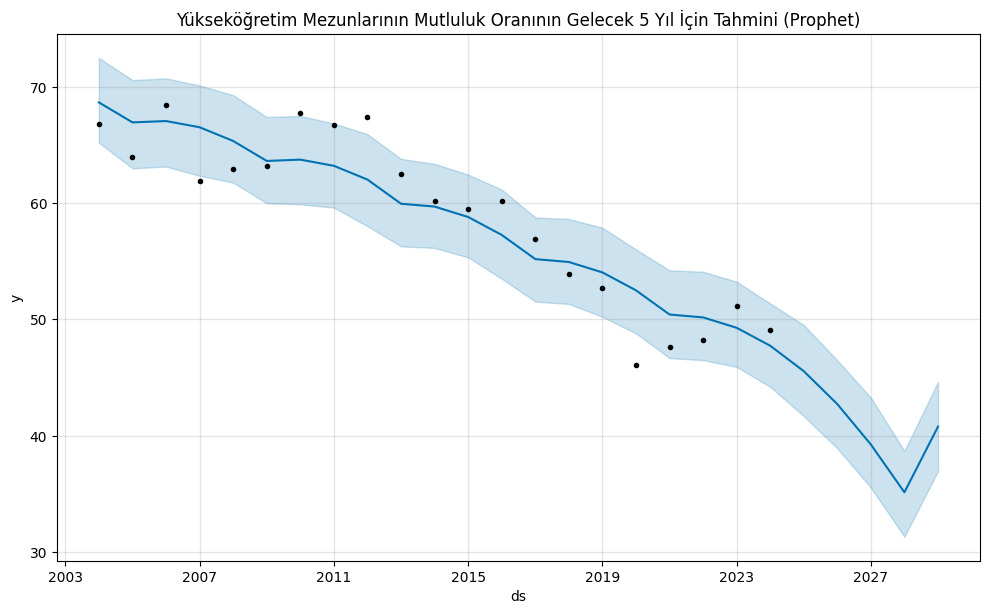

In [40]:
from prophet import Prophet

# Prophet için veri formatı
df_prophet = df_edu[["Yıl", "Mutlu - Yükseköğretim"]].rename(columns={"Yıl": "ds", "Mutlu - Yükseköğretim": "y"})
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

# Prophet modelini oluştur ve eğit
prophet_model = Prophet()
prophet_model.fit(df_prophet)

# Gelecek 5 yıl için tahmin yap
future = prophet_model.make_future_dataframe(periods=5, freq="Y")
forecast = prophet_model.predict(future)

# Sonuçları görselleştir
fig = prophet_model.plot(forecast)
plt.title("Yükseköğretim Mezunlarının Mutluluk Oranının Gelecek 5 Yıl İçin Tahmini (Prophet)")
plt.show()


## Türkiye’de Mutluluk Kaynaklarının 2004-2024 Yılları Arasındaki Değişimi

In [41]:
# önce veriyi düzenleyelim

In [42]:
import pandas as pd

data = {
    "Yıl": list(range(2004, 2025)),
    "Tüm Aile": [69.5, 68.2, 67.3, 69.5, 70.1, 71.2, 70.9, 73.8, 69.6, 73.0, 73.3, 72.3, 70.2, 70.6, 74.2, 74.1, 69.7, 67.6, 67.6, 69.9, 72.9],
    "Çocuklar": [13.2, 13.9, 14.0, 12.0, 14.0, 12.7, 13.2, 12.2, 13.9, 12.9, 13.4, 13.1, 15.1, 14.3, 12.9, 12.8, 15.0, 16.8, 16.3, 15.0, 13.2],
    "Eş": [8.2, 9.3, 9.4, 9.3, 7.2, 6.9, 7.5, 6.2, 7.0, 5.2, 5.0, 5.3, 4.7, 5.4, 3.6, 3.7, 3.5, 4.1, 3.9, 3.8, 3.4],
    "Anne/Baba": [3.1, 3.1, 3.8, 3.6, 3.1, 3.2, 3.1, 2.9, 3.5, 2.9, 3.1, 2.8, 3.6, 3.2, 2.7, 2.5, 3.6, 4.0, 3.8, 2.9, 3.0],
    "Kendisi": [2.0, 1.7, 1.5, 2.2, 2.0, 2.4, 1.9, 1.8, 2.2, 2.5, 1.9, 2.7, 2.7, 3.4, 3.3, 3.8, 4.2, 4.0, 4.8, 5.4, 4.2],
    "Torunlar": [1.8, 1.7, 1.5, 1.6, 1.7, 1.5, 1.2, 1.4, 2.0, 1.7, 1.4, 1.9, 1.9, 1.9, 1.8, 1.6, 2.2, 2.1, 1.9, 1.8, 1.9],
    "Diğer (Kişiler)": [2.3, 2.2, 2.6, 1.7, 1.9, 2.2, 2.2, 1.7, 1.8, 1.9, 2.1, 1.9, 1.7, 1.2, 1.4, 1.5, 1.9, 1.5, 1.8, 1.3, 1.5],
    "Sağlık": [67.1, 69.2, 72.1, 68.7, 71.1, 70.7, 71.2, 72.8, 70.8, 68.0, 68.8, 68.8, 72.1, 68.0, 69.0, 69.9, 70.9, 69.0, 68.2, 69.5, 68.3],
    "Sevgi": [14.6, 11.9, 11.2, 13.5, 11.8, 13.2, 13.0, 13.1, 13.8, 15.2, 15.4, 15.8, 14.6, 16.6, 15.5, 14.3, 12.8, 14.3, 13.2, 13.2, 14.4],
    "Başarı": [6.1, 5.5, 6.3, 6.4, 5.7, 6.6, 6.9, 6.9, 6.7, 8.6, 8.5, 8.6, 7.0, 9.0, 8.8, 9.2, 8.8, 8.9, 9.5, 9.2, 8.9],
    "Para": [6.1, 5.9, 4.7, 6.4, 5.4, 5.2, 4.6, 4.3, 5.1, 4.1, 4.2, 3.9, 3.2, 3.9, 4.2, 4.2, 4.6, 5.1, 6.2, 5.3, 6.4],
    "İş": [4.3, 5.0, 3.9, 2.9, 3.8, 3.5, 3.5, 2.4, 3.1, 2.3, 2.2, 2.0, 2.3, 1.9, 2.2, 2.1, 2.3, 2.3, 2.6, 2.6, 1.8],
    "Diğer (Değerler)": [1.8, 2.5, 1.8, 2.2, 2.2, 0.8, 0.9, 0.5, 0.6, 1.8, 0.9, 1.0, 0.8, 0.6, 0.2, 0.3, 0.7, 0.4, 0.3, 0.2, 0.2]
}


df_happiness = pd.DataFrame(data)


csv_path = "mutluluk_kaynagi_cleaned.csv"
df_happiness.to_csv(csv_path, index=False)


In [43]:
df = pd.read_csv("mutluluk_kaynagi_cleaned.csv")

df.head(50)

,Yıl,Tüm Aile,Çocuklar,Eş,Anne/Baba,Kendisi,Torunlar,Diğer (Kişiler),Sağlık,Sevgi,Başarı,Para,İş,Diğer (Değerler)
0,2004,69.5,13.2,8.2,3.1,2.0,1.8,2.3,67.1,14.6,6.1,6.1,4.3,1.8
1,2005,68.2,13.9,9.3,3.1,1.7,1.7,2.2,69.2,11.9,5.5,5.9,5.0,2.5
2,2006,67.3,14.0,9.4,3.8,1.5,1.5,2.6,72.1,11.2,6.3,4.7,3.9,1.8
3,2007,69.5,12.0,9.3,3.6,2.2,1.6,1.7,68.7,13.5,6.4,6.4,2.9,2.2
4,2008,70.1,14.0,7.2,3.1,2.0,1.7,1.9,71.1,11.8,5.7,5.4,3.8,2.2
5,2009,71.2,12.7,6.9,3.2,2.4,1.5,2.2,70.7,13.2,6.6,5.2,3.5,0.8
6,2010,70.9,13.2,7.5,3.1,1.9,1.2,2.2,71.2,13.0,6.9,4.6,3.5,0.9
7,2011,73.8,12.2,6.2,2.9,1.8,1.4,1.7,72.8,13.1,6.9,4.3,2.4,0.5
8,2012,69.6,13.9,7.0,3.5,2.2,2.0,1.8,70.8,13.8,6.7,5.1,3.1,0.6
9,2013,73.0,12.9,5.2,2.9,2.5,1.7,1.9,68.0,15.2,8.6,4.1,2.3,1.8


In [44]:
# Veri hakkında genel bilgi
df.info()

# Temel istatistiksel özet
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Yıl               21 non-null     int64  
 1   Tüm Aile          21 non-null     float64
 2   Çocuklar          21 non-null     float64
 3   Eş                21 non-null     float64
 4   Anne/Baba         21 non-null     float64
 5   Kendisi           21 non-null     float64
 6   Torunlar          21 non-null     float64
 7   Diğer (Kişiler)   21 non-null     float64
 8   Sağlık            21 non-null     float64
 9   Sevgi             21 non-null     float64
 10  Başarı            21 non-null     float64
 11  Para              21 non-null     float64
 12  İş                21 non-null     float64
 13  Diğer (Değerler)  21 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 2.4 KB


,Yıl,Tüm Aile,Çocuklar,Eş,Anne/Baba,Kendisi,Torunlar,Diğer (Kişiler),Sağlık,Sevgi,Başarı,Para,İş,Diğer (Değerler)
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,2014.000000,70.738095,13.804762,5.838095,3.214286,2.885714,1.738095,1.823810,69.723810,13.876190,7.719048,4.904762,2.809524,0.985714
std,6.204837,2.196697,1.255578,2.052675,0.399106,1.126182,0.247944,0.357638,1.575724,1.395315,1.341871,0.916229,0.874016,0.743832
min,2004.000000,67.300000,12.000000,3.400000,2.500000,1.500000,1.200000,1.200000,67.100000,11.200000,5.500000,3.200000,1.800000,0.200000
25%,2009.000000,69.500000,12.900000,3.900000,2.900000,2.000000,1.600000,1.500000,68.700000,13.100000,6.600000,4.200000,2.200000,0.400000
50%,2014.000000,70.200000,13.400000,5.300000,3.100000,2.500000,1.800000,1.800000,69.200000,13.800000,8.500000,4.700000,2.400000,0.800000
75%,2019.000000,72.900000,14.300000,7.200000,3.600000,3.800000,1.900000,2.100000,70.900000,14.600000,8.900000,5.400000,3.500000,1.800000
max,2024.000000,74.200000,16.800000,9.400000,4.000000,5.400000,2.200000,2.600000,72.800000,16.600000,9.500000,6.400000,5.000000,2.500000


In [45]:
# Eksik veri kontrolü
missing_values = df.isnull().sum()
print(missing_values)

Yıl                 0
Tüm Aile            0
Çocuklar            0
Eş                  0
Anne/Baba           0
Kendisi             0
Torunlar            0
Diğer (Kişiler)     0
Sağlık              0
Sevgi               0
Başarı              0
Para                0
İş                  0
Diğer (Değerler)    0
dtype: int64


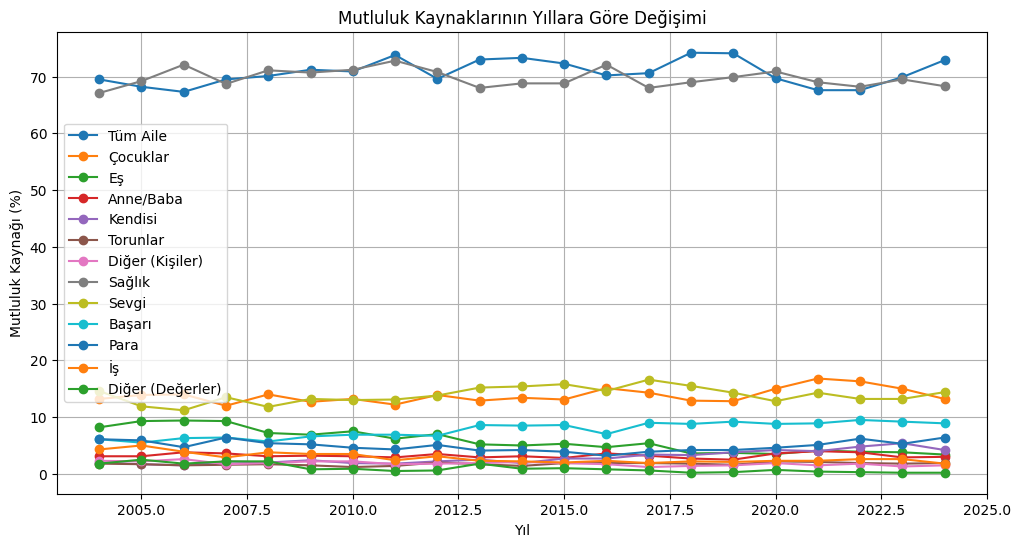

In [46]:
plt.figure(figsize=(12,6))

# Yıllara göre değişimi çizelim
for column in df.columns[1:]:
    plt.plot(df["Yıl"], df[column], marker="o", label=column)

plt.xlabel("Yıl")
plt.ylabel("Mutluluk Kaynağı (%)")
plt.title("Mutluluk Kaynaklarının Yıllara Göre Değişimi")
plt.legend()
plt.grid()
plt.show()


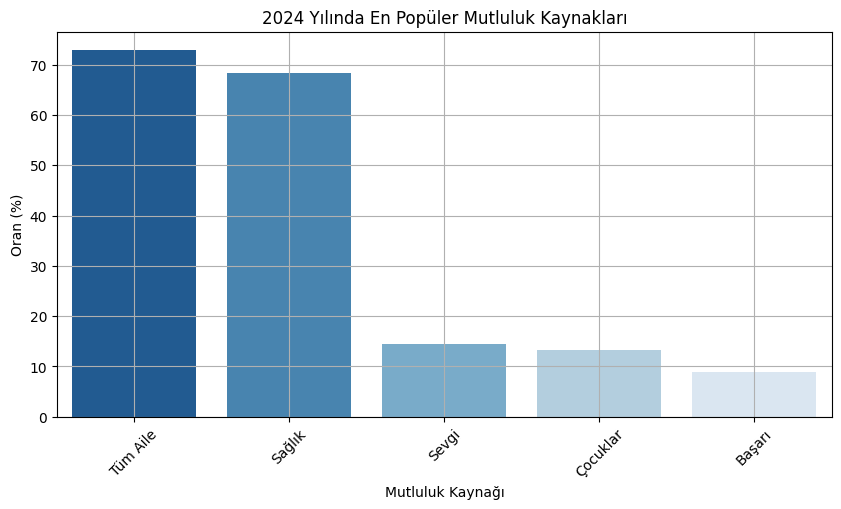

In [47]:
# Son yıla göre en popüler mutluluk kaynaklarını bul
latest_year = df.iloc[-1, 1:]
top_sources = latest_year.nlargest(5)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sources.index, y=top_sources.values, palette="Blues_r")
plt.xlabel("Mutluluk Kaynağı")
plt.ylabel("Oran (%)")
plt.title(f"{df.iloc[-1, 0]} Yılında En Popüler Mutluluk Kaynakları")
plt.xticks(rotation=45)
plt.grid()
plt.show()


16:24:48 - cmdstanpy - INFO - Chain [1] start processing
16:24:48 - cmdstanpy - INFO - Chain [1] done processing


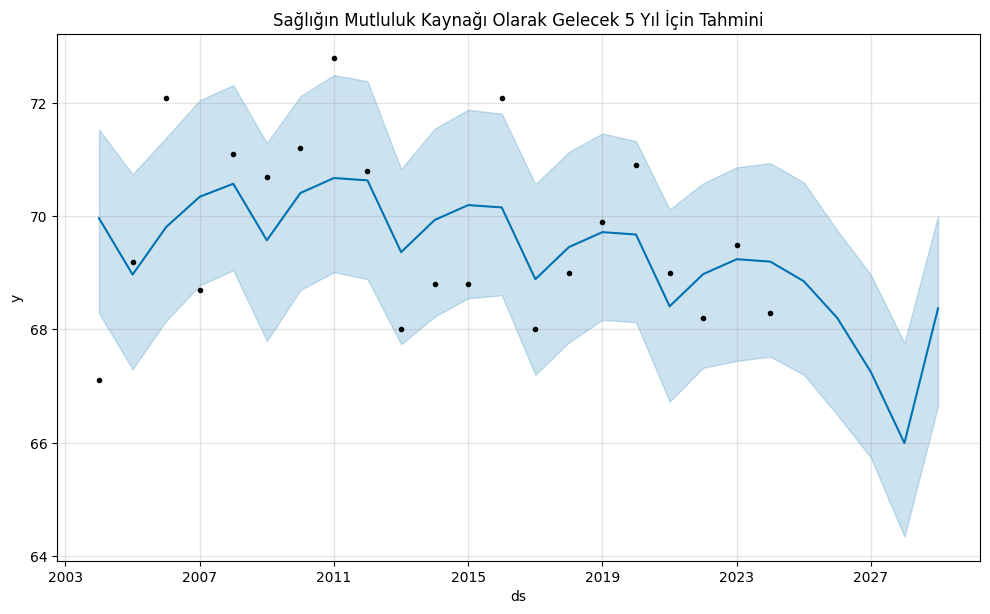

In [48]:
# Prophet için veri formatı
df_prophet = df[["Yıl", "Sağlık"]].rename(columns={"Yıl": "ds", "Sağlık": "y"})
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

# Prophet modelini oluştur ve eğit
prophet_model = Prophet()
prophet_model.fit(df_prophet)

# Gelecek 5 yıl için tahmin yap
future = prophet_model.make_future_dataframe(periods=5, freq="Y")
forecast = prophet_model.predict(future)

# Sonuçları görselleştir
fig = prophet_model.plot(forecast)
plt.title("Sağlığın Mutluluk Kaynağı Olarak Gelecek 5 Yıl İçin Tahmini")
plt.show()


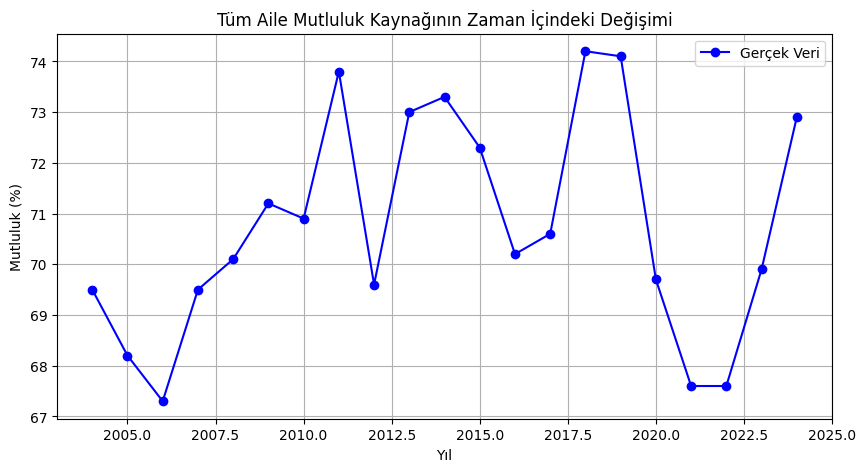

In [49]:
import statsmodels.api as sm

# "Tüm Aile" verisini zaman serisi olarak alalım
family_series = df[["Yıl", "Tüm Aile"]].copy()
family_series.set_index("Yıl", inplace=True)

# ARIMA modeli için veriyi görselleştirelim
plt.figure(figsize=(10,5))
plt.plot(family_series, marker="o", linestyle="-", color="b", label="Gerçek Veri")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk (%)")
plt.title("Tüm Aile Mutluluk Kaynağının Zaman İçindeki Değişimi")
plt.legend()
plt.grid()
plt.show()


In [50]:
# ARIMA modelini oluştur ve eğit
arima_model = sm.tsa.ARIMA(family_series, order=(3,1,2))  # (p,d,q) değerlerini optimize edebiliriz
arima_fit = arima_model.fit()

# 5 yıl ileriye tahmin yap (2025 - 2029)
arima_forecast = arima_fit.forecast(steps=5)
future_years = list(range(2025, 2030))

# Sonuçları göster
for year, value in zip(future_years, arima_forecast):
    print(f"{year}: {value:.2f}")


2025: 71.34
2026: 69.38
2027: 68.62
2028: 69.98
2029: 71.20


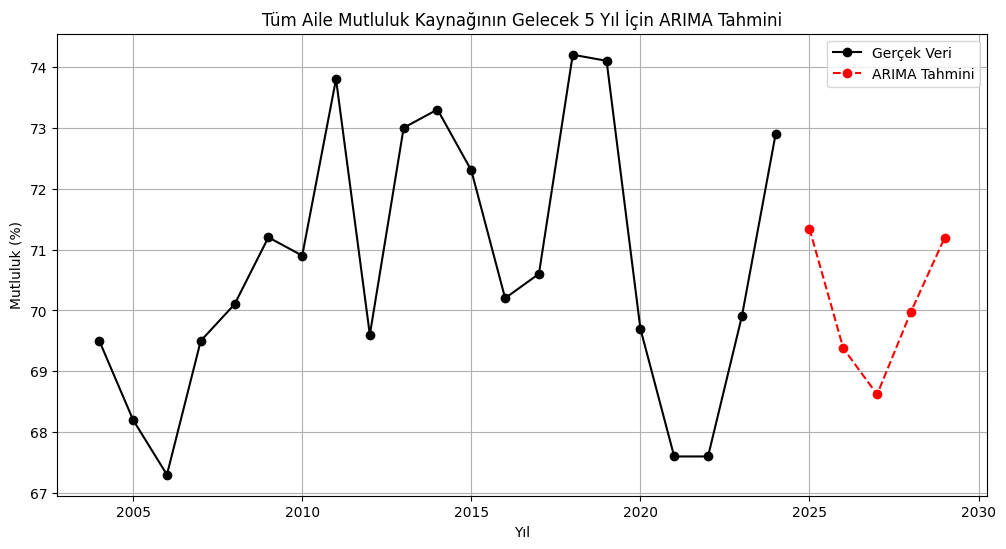

In [51]:
# Tahminleri görselleştirme
plt.figure(figsize=(12,6))

# Gerçek veri
plt.plot(family_series, label="Gerçek Veri", marker="o", linestyle="-", color="black")

# ARIMA tahmini
plt.plot(future_years, arima_forecast, label="ARIMA Tahmini", linestyle="dashed", marker="o", color="red")

# Başlık ve etiketler
plt.title("Tüm Aile Mutluluk Kaynağının Gelecek 5 Yıl İçin ARIMA Tahmini")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk (%)")
plt.legend()
plt.grid()

# Grafiği göster
plt.show()


In [52]:
from prophet import Prophet
import pandas as pd

# Tahmin sonuçlarını saklayacağımız bir sözlük
future_changes = {}

# Tüm mutluluk kaynakları için tahmin yapalım
for column in df.columns[1:]:  # İlk sütun "Yıl", bunu almayacağız
    print(f"Tahmin yapılıyor: {column}")

    # Prophet için veri formatı
    df_prophet = df[["Yıl", column]].rename(columns={"Yıl": "ds", column: "y"})
    df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

    # Prophet modelini oluştur ve eğit
    prophet_model = Prophet()
    prophet_model.fit(df_prophet)

    # Gelecek 5 yıl için tahmin yap
    future = prophet_model.make_future_dataframe(periods=6, freq="Y")
    forecast = prophet_model.predict(future)

    # 2024 ve 2029 yıllarına en yakın tahmin değerlerini bulalım
    closest_2024 = forecast.loc[(forecast["ds"] >= "2024-01-01")].iloc[0]["yhat"]
    closest_2029 = forecast.loc[(forecast["ds"] >= "2029-01-01")].iloc[0]["yhat"]

    # Değişimi hesapla
    change = closest_2029 - closest_2024
    future_changes[column] = change

# Sonuçları sıralayalım
sorted_changes = sorted(future_changes.items(), key=lambda x: x[1], reverse=True)

# En çok artış gösteren mutluluk kaynağını yazdıralım
most_increased = sorted_changes[0]
print(f"📈 Gelecek 5 yılda en çok artış gösteren mutluluk kaynağı: {most_increased[0]} (+{most_increased[1]:.2f})")


16:24:51 - cmdstanpy - INFO - Chain [1] start processing


Tahmin yapılıyor: Tüm Aile


16:24:51 - cmdstanpy - INFO - Chain [1] done processing


Tahmin yapılıyor: Çocuklar


16:24:51 - cmdstanpy - INFO - Chain [1] start processing
16:24:52 - cmdstanpy - INFO - Chain [1] done processing
16:24:52 - cmdstanpy - INFO - Chain [1] start processing


...

Tahmin yapılıyor: Para


16:24:55 - cmdstanpy - INFO - Chain [1] start processing


Tahmin yapılıyor: İş


16:24:55 - cmdstanpy - INFO - Chain [1] done processing
16:24:55 - cmdstanpy - INFO - Chain [1] start processing
16:24:55 - cmdstanpy - INFO - Chain [1] done processing


Tahmin yapılıyor: Diğer (Değerler)
📈 Gelecek 5 yılda en çok artış gösteren mutluluk kaynağı: Çocuklar (+1.54)


In [55]:
# ---------------- VERİYİ İÇE AKTARMA ----------------
df = pd.read_csv("mutluluk_verisi.csv")  # CSV dosya adını güncelle
df["Year"] = pd.to_datetime(df["Year"], format="%Y")  # Yılı datetime formatına çevir
df.set_index("Year", inplace=True)  # Yılı indeks yap

In [56]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


# Örnek olarak 2007–2018 train, 2019–2024 test
train = df.loc["2007":"2018"].copy()
test  = df.loc["2019":"2024"].copy()

# Özellikler ve hedef değişken
features = ["Log GDP Per Capita", 
            "Social Support", 
            "Healthy Life Expectancy At Birth", 
            "Freedom To Make Life Choices", 
            "Perceptions Of Corruption"]
target = "Life Ladder"

# 2022 ve 2024 hatalı olduğu için çıkar
temiz_test = test.drop(["2022-01-01", "2024-01-01"])

# Eğitim ve test setleri
X_train = train[features]
y_train = train[target]

X_test = temiz_test[features]
y_test = temiz_test[target]

# Kullanılacak modeller
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR (RBF Kernel)": SVR(kernel='rbf')
}

# Sonuçları saklamak için liste
results = []

# Her modeli sırayla eğit ve değerlendir
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "MAPE (%)": round(mape, 2),
        "R²": round(r2, 3)
    })

# Sonuçları tablo halinde göster
results_df = pd.DataFrame(results)
print(results_df.sort_values("RMSE"))


               Model    MAE   RMSE  MAPE (%)      R²
0  Linear Regression  0.237  0.243      5.13  -0.366
4  Gradient Boosting  0.548  0.585     11.92  -6.952
3      Random Forest  0.601  0.632     13.06  -8.261
2   Lasso Regression  0.665  0.697     14.45 -10.273
1   Ridge Regression  0.670  0.700     14.55 -10.360
5   SVR (RBF Kernel)  0.703  0.733     15.26 -11.475


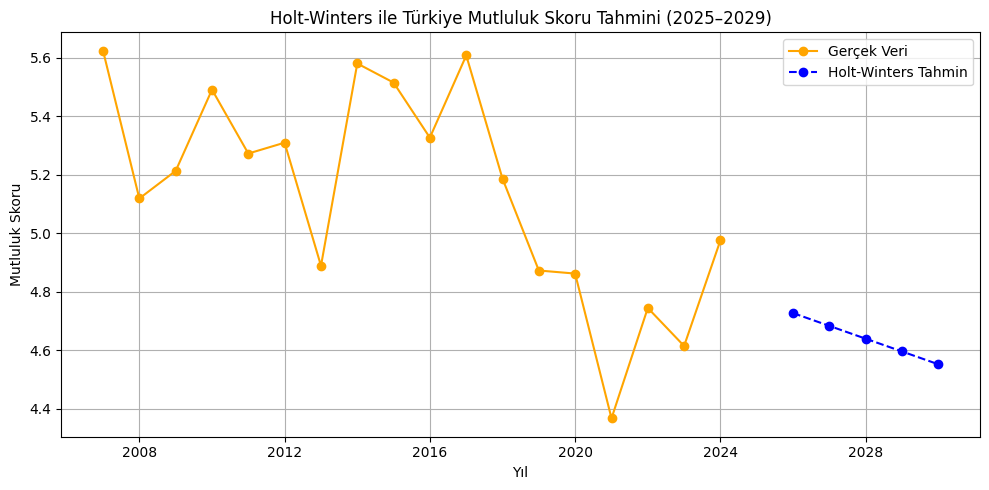

📌 Holt-Winters 2025–2029 Tahminleri:
            Life Ladder Prediction
Year                              
2025-12-31                4.726573
2026-12-31                4.682816
2027-12-31                4.639059
2028-12-31                4.595302
2029-12-31                4.551545


In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Veriyi yükle
df = pd.read_csv("mutluluk_verisi.csv")
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df.set_index("Year", inplace=True)

# Hedef değişken
series = df["Life Ladder"].dropna()

# Modeli kur (trendli, yıllık veride mevsimsellik gerekmez)
hw_model = ExponentialSmoothing(series, trend="add", seasonal=None).fit()

# 5 yıl ileri tahmin (2025–2029)
forecast_hw = hw_model.forecast(steps=5)

# Tahminleri DataFrame'e çevir
forecast_hw_df = pd.DataFrame({
    "Year": pd.date_range(start="2025", periods=5, freq="Y"),
    "Life Ladder Prediction": forecast_hw
}).set_index("Year")

# Grafik çizimi
plt.figure(figsize=(10, 5))
plt.plot(series.index, series.values, label="Gerçek Veri", marker="o", color="orange")
plt.plot(forecast_hw_df.index, forecast_hw_df["Life Ladder Prediction"], label="Holt-Winters Tahmin", linestyle="--", marker="o", color="blue")
plt.title("Holt-Winters ile Türkiye Mutluluk Skoru Tahmini (2025–2029)")
plt.xlabel("Yıl")
plt.ylabel("Mutluluk Skoru")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Tahminleri yazdır
print("📌 Holt-Winters 2025–2029 Tahminleri:")
print(forecast_hw_df)


In [58]:
# Eğitim ve test ayrımı
train_hw = df.loc["2007":"2018"]["Life Ladder"]
test_hw = df.loc["2019":"2024"]["Life Ladder"]


In [59]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Modeli eğit (trendli model, mevsimsizlik yok)
model_hw = ExponentialSmoothing(train_hw, trend="add", seasonal=None).fit()

# 6 yıllık tahmin (2019–2024)
forecast_hw_test = model_hw.forecast(steps=6)

# Gerçek ve tahmin değerleri
y_true_hw = test_hw.values
y_pred_hw = forecast_hw_test.values

# Performans metrikleri
mae_hw = mean_absolute_error(y_true_hw, y_pred_hw)
rmse_hw = np.sqrt(mean_squared_error(y_true_hw, y_pred_hw))
mape_hw = np.mean(np.abs((y_true_hw - y_pred_hw) / y_true_hw)) * 100

# Sonuçları yazdır
print("✅ Holt-Winters Performansı (2019–2024)")
print(f"MAE  : {mae_hw:.3f}")
print(f"RMSE : {rmse_hw:.3f}")
print(f"MAPE : {mape_hw:.2f}%")


✅ Holt-Winters Performansı (2019–2024)
MAE  : 0.637
RMSE : 0.668
MAPE : 13.65%
